# TCC - Análise do Trânsito no Recife

Bases: **Lombadas** (velocidade — 19 arquivos mensais, 2025/2026), **Semáforos**, **Faixas e Corredores Exclusivos**.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import networkx as nx
from itertools import combinations

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_theme(style="whitegrid")

try:
    display
except NameError:
    def display(*args, **kwargs):
        for a in args:
            print(a)

PASTA_DADOS = 'dados'  # <-- ajuste aqui se necessário

## Bases auxiliares (Semáforos, Faixas e Corredores)

As Lombadas (19 arquivos mensais) são tratadas à parte, mais abaixo — aqui carregamos só as demais bases da pasta.

In [2]:
def ler_csv_robusto(caminho):
    combinacoes = [
        dict(sep=None, engine='python', encoding='utf-8'),
        dict(sep=None, engine='python', encoding='latin1'),
        dict(sep=';', encoding='utf-8'),
        dict(sep=';', encoding='latin1'),
        dict(sep=',', encoding='utf-8'),
        dict(sep=',', encoding='latin1'),
    ]
    ultimo_erro = None
    for opcoes in combinacoes:
        try:
            tabela = pd.read_csv(caminho, **opcoes)
            if tabela.shape[1] > 1:
                return tabela, opcoes
        except Exception as erro:
            ultimo_erro = erro
    raise ultimo_erro

caminhos = glob.glob(os.path.join(PASTA_DADOS, '*.csv'))
caminhos = [c for c in caminhos if 'lombadas' not in os.path.basename(c).lower()]

if not caminhos:
    raise FileNotFoundError(
        f"Nenhum .csv encontrado em '{PASTA_DADOS}' (fora das Lombadas). "
        "Confira se a pasta existe e tem os arquivos."
    )

dfs = {}
for caminho in caminhos:
    chave = os.path.splitext(os.path.basename(caminho))[0]
    tabela, opcoes_usadas = ler_csv_robusto(caminho)
    dfs[chave] = tabela
    print(f"\nArquivo: {chave}")
    print(f"Formato: {tabela.shape[0]} linhas x {tabela.shape[1]} colunas")
    print(f"Leitura: {opcoes_usadas}")


Arquivo: 36c2b47b-f439-4895-8b65-3f3dda36a4a7
Formato: 87 linhas x 13 colunas
Leitura: {'sep': None, 'engine': 'python', 'encoding': 'utf-8'}

Arquivo: Faixas e Corredores Exclusivos
Formato: 9 linhas x 6 colunas
Leitura: {'sep': None, 'engine': 'python', 'encoding': 'utf-8'}

Arquivo: Semáforos do Recife
Formato: 712 linhas x 9 colunas
Leitura: {'sep': None, 'engine': 'python', 'encoding': 'utf-8'}


In [3]:
for chave, tabela in dfs.items():
    print("\n" + "=" * 70)
    print(chave)
    print("=" * 70)

    print(f"Linhas: {tabela.shape[0]} | Colunas: {tabela.shape[1]}")
    print("Colunas:", list(tabela.columns))

    resumo = pd.DataFrame({
        'coluna': tabela.columns,
        'tipo': tabela.dtypes.astype(str).values,
        'nulos': tabela.isnull().sum().values,
        'percentual_nulos': (tabela.isnull().sum().values / len(tabela) * 100).round(2),
        'valores_unicos': [tabela[c].nunique(dropna=True) for c in tabela.columns],
    })
    display(resumo)

    print("Duplicatas exatas:", tabela.duplicated().sum())
    display(tabela.head())


36c2b47b-f439-4895-8b65-3f3dda36a4a7
Linhas: 87 | Colunas: 13
Colunas: ['\ufeff_id', 'tipo_equipamento', 'registro_inmetro', 'numero_serie_fabricante', 'identificacao_equipamento', 'local_instalacao', 'sentido_fiscalizacao', 'latitude', 'longitude', 'faixas_fiscalizadas', 'velocidade_fiscalizada', 'vmd', 'periodo_vmd']


,coluna,tipo,nulos,percentual_nulos,valores_unicos
0,﻿_id,int64,0,0.0,87
1,tipo_equipamento,str,0,0.0,1
2,registro_inmetro,str,0,0.0,2
3,numero_serie_fabricante,str,0,0.0,86
4,identificacao_equipamento,str,0,0.0,86
5,local_instalacao,str,0,0.0,77
6,sentido_fiscalizacao,str,0,0.0,15
7,latitude,float64,0,0.0,80
8,longitude,float64,0,0.0,80
9,faixas_fiscalizadas,int64,0,0.0,3


Duplicatas exatas: 0


,﻿_id,tipo_equipamento,registro_inmetro,numero_serie_fabricante,identificacao_equipamento,local_instalacao,sentido_fiscalizacao,latitude,longitude,faixas_fiscalizadas,velocidade_fiscalizada,vmd,periodo_vmd
0,1,FIXO,Portaria 018/2018-243/2022,R13727,9111,"AV. GENERAL SAN MARTIN, N. 1864",DOIS SENTIDOS,-8.067404,-34.927845,2,40 Km/h,22500,set/25
1,2,FIXO,Portaria 018/2018-243/2022,R14646,9438,"AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669",SUBURBIO,-8.115720,-34.904324,2,50 Km/h,16100,set/25
2,3,FIXO,Portaria 018/2018-243/2022,R14647,9439,"AV. ENG. JOS ESTELITA, APàS PTE. AGAMENON MAG...",DERBY,-8.080763,-34.891213,2,60 Km/h,40500,set/25
3,4,FIXO,Portaria 018/2018-243/2022,R14655,9440,"AV. ENG. JOS ESTELITA, APàS PTE. AGAMENON MAG...",DERBY,-8.080763,-34.891213,2,60 Km/h,42600,set/25
4,5,FIXO,Portaria 018/2018-243/2022,R14643,9442,"AV. BOA VIAGEM, ENTRE O N. 2080 E 1906",-,-8.107843,-34.888161,3,60 Km/h,24400,set/25



Faixas e Corredores Exclusivos
Linhas: 9 | Colunas: 6
Colunas: ['faixa_azul', 'bairro', 'detalhe', 'extensão', 'mes_implantacao', 'ano_implantacao']


...

,faixa_azul,bairro,detalhe,extensão,mes_implantacao,ano_implantacao
0,Rua Cosme Viana,Afogados,Da Av. Eng. Abdias de Carvalho até Rua Dr. Ade...,1.6 km,dezembro,2013
1,Avenida Marechal Mascarenhas de Moraes,Imbiribeira,Da Rua Júlio Verne até Avenida Presidente Dutr...,14 km,janeiro,2014
2,Avenida Domingos Ferreira /Avenida Herculano B...,"Boa Viagem, Pina",Da Rua Arq. Augusto Reinaldo até Rua Barão de ...,6 km,junho,2014
3,Rua Real da Torre,Torre,Da Rua Marcos André até Rua José Osório,1.5 km,agosto,2015
4,Avenida Conselheiro Aguiar,Boa Viagem,Da Rua Barão de Souza Leão até Av. Antônio de ...,5.2 km,janeiro,2016



Semáforos do Recife
Linhas: 712 | Colunas: 9
Colunas: ['semaforo', 'localizacao1', 'localizacao2', 'bairro', 'latitude', 'longitude', 'tipo', 'funcionamento', 'Unnamed: 8']


,coluna,tipo,nulos,percentual_nulos,valores_unicos
0,semaforo,int64,0,0.00,712
1,localizacao1,str,0,0.00,234
2,localizacao2,str,0,0.00,591
3,bairro,str,0,0.00,86
4,latitude,str,0,0.00,710
5,longitude,float64,0,0.00,705
6,tipo,str,0,0.00,4
7,funcionamento,str,0,0.00,8
8,Unnamed: 8,float64,86,12.08,1


Duplicatas exatas: 0


,semaforo,localizacao1,localizacao2,bairro,latitude,longitude,tipo,funcionamento,Unnamed: 8
0,1,Av. Boa Viagem,Em frente ao parque Dona Lindú,BOA VIAGEM,-8.142323,-34.903798,E/Git,Ocasional/Ped.,1.0
1,2,Av. Conselheiro Aguiar,Rua Thomé Gibson,BOA VIAGEM,-8.099068,-34.885883,E/Git,Veicular,1.0
2,3,Av. Boa Viagem,Rua França Pereira,BOA VIAGEM,-8.106806,-34.887726,E/Git,Ocasional/Ped.,1.0
3,4,Av. Boa Viagem,Rua Barão de Souza Leão,BOA VIAGEM,-8.132230,-34.899990,E/Git,Ocasional/Ped.,1.0
4,5,Av. Conselheiro Aguiar,Rua Artur Muniz,BOA VIAGEM,-8.104310,-34.888228,E/Git,Veicular,1.0


In [4]:
dfs_limpos = {}

for chave, tabela in dfs.items():
    t = tabela.copy()

    # 1. Remover espaços extras das colunas de texto
    colunas_texto = t.select_dtypes(include='object').columns
    for coluna in colunas_texto:
        t[coluna] = t[coluna].apply(
            lambda valor: valor.strip() if isinstance(valor, str) else valor
        )

    # 2. Remover colunas completamente vazias
    colunas_vazias = [c for c in t.columns if t[c].isna().all()]
    if colunas_vazias:
        print(f"{chave}: colunas completamente vazias (removidas): {colunas_vazias}")
        t = t.drop(columns=colunas_vazias)

    # 3. Duplicatas e nulos: só reportar, não tratar ainda
    print(f"{chave}: duplicatas={t.duplicated().sum()}, nulos totais={t.isnull().sum().sum()}")

    dfs_limpos[chave] = t

36c2b47b-f439-4895-8b65-3f3dda36a4a7: duplicatas=0, nulos totais=0
Faixas e Corredores Exclusivos: duplicatas=0, nulos totais=0
Semáforos do Recife: duplicatas=0, nulos totais=86


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17240\642711011.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = t.select_dtypes(include='object').columns
C:\Users\Usuario\AppData\Local\Temp\ipykernel_17240\642711011.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_g

## Semáforos

In [5]:
for chave, tabela in dfs_limpos.items():
    if 'sem' not in chave.lower():
        continue

    print("\n" + "=" * 70)
    print(f"BASE: {chave}")
    print("=" * 70)
    print(f"Formato: {tabela.shape}")
    print("Colunas:", list(tabela.columns))

    if 'bairro' in tabela.columns:
        print("\nBairros com mais registros:")
        display(tabela['bairro'].value_counts().head(20))
    if 'tipo' in tabela.columns:
        print("\nTipos de semáforo:")
        display(tabela['tipo'].value_counts())
    if 'funcionamento' in tabela.columns:
        print("\nFuncionamento:")
        display(tabela['funcionamento'].value_counts())


BASE: Semáforos do Recife
Formato: (712, 9)
Colunas: ['semaforo', 'localizacao1', 'localizacao2', 'bairro', 'latitude', 'longitude', 'tipo', 'funcionamento', 'Unnamed: 8']

Bairros com mais registros:


bairro
BOA VIAGEM       100
IMBIRIBEIRA       46
BOA VISTA         39
SANTO AMARO       37
CORDEIRO          27
SANTO ANTÔNIO     24
SÃO JOSÉ          22
MADALENA          20
AFOGADOS          18
CASA AMARELA      18
IPUTINGA          17
GRAÇAS            17
PINA              17
DERBY             15
ESPINHEIRO        13
TORRE             13
CAMPO GRANDE      12
CASA FORTE        12
IPSEP             10
ENCRUZILHADA       9
Name: count, dtype: int64


Tipos de semáforo:


tipo
E/Git    557
E        137
E/DIG     15
E/GIt      3
Name: count, dtype: int64


Funcionamento:


funcionamento
Veicular             336
Ocasional/Ped.       217
Veic.C/Ped.Paral.     58
Veic.C/Ped.Ocas.      48
Veic.C/Ped.           32
Pedestre              14
Veic.c/Ped.Ocas.       6
Veic.C/Laço Det.       1
Name: count, dtype: int64

In [6]:
for chave, tabela in dfs_limpos.items():
    if 'sem' not in chave.lower():
        continue

    for coluna in ['latitude', 'longitude']:
        if coluna in tabela.columns:
            print(f"\n{coluna} — antes da conversão:")
            print("Tipo:", tabela[coluna].dtype, "| Nulos:", tabela[coluna].isnull().sum())

            tabela[coluna] = tabela[coluna].astype(str).str.replace(',', '.', regex=False)
            tabela[coluna] = pd.to_numeric(tabela[coluna], errors='coerce')

    print(f"\n{chave} — coordenadas depois da conversão:")
    display(tabela[['latitude', 'longitude']].describe())


latitude — antes da conversão:
Tipo: str | Nulos: 0

longitude — antes da conversão:
Tipo: float64 | Nulos: 0

Semáforos do Recife — coordenadas depois da conversão:


,latitude,longitude
count,711.000000,712.000000
mean,-8.069528,-34.905326
std,0.034427,0.019771
min,-8.151128,-34.968542
25%,-8.096993,-34.915994
50%,-8.061105,-34.903534
75%,-8.043375,-34.889985
max,-8.004059,-34.870390


## Faixas e Corredores Exclusivos

In [7]:
for chave, tabela in dfs_limpos.items():
    if 'faixa' not in chave.lower() and 'corredor' not in chave.lower():
        continue

    print("\n" + "=" * 70)
    print(f"BASE: {chave}")
    print("=" * 70)
    print(f"Formato: {tabela.shape}")
    print("Colunas:", list(tabela.columns))
    display(tabela)

    if 'ano_implantacao' in tabela.columns:
        print("\nAnos de implantação:")
        display(tabela['ano_implantacao'].value_counts().sort_index())
    if 'bairro' in tabela.columns:
        print("\nBairros:")
        display(tabela['bairro'].value_counts())

    if 'extensão' in tabela.columns:
        tabela['extensao_km'] = (
            tabela['extensão']
            .astype(str)
            .str.replace('km', '', case=False, regex=False)
            .str.replace(',', '.', regex=False)
            .str.strip()
        )
        tabela['extensao_km'] = pd.to_numeric(tabela['extensao_km'], errors='coerce')
        print("\nExtensão convertida:")
        display(tabela[['extensão', 'extensao_km']])


BASE: Faixas e Corredores Exclusivos
Formato: (9, 6)
Colunas: ['faixa_azul', 'bairro', 'detalhe', 'extensão', 'mes_implantacao', 'ano_implantacao']


,faixa_azul,bairro,detalhe,extensão,mes_implantacao,ano_implantacao
0,Rua Cosme Viana,Afogados,Da Av. Eng. Abdias de Carvalho até Rua Dr. Ade...,1.6 km,dezembro,2013
1,Avenida Marechal Mascarenhas de Moraes,Imbiribeira,Da Rua Júlio Verne até Avenida Presidente Dutr...,14 km,janeiro,2014
2,Avenida Domingos Ferreira /Avenida Herculano B...,"Boa Viagem, Pina",Da Rua Arq. Augusto Reinaldo até Rua Barão de ...,6 km,junho,2014
3,Rua Real da Torre,Torre,Da Rua Marcos André até Rua José Osório,1.5 km,agosto,2015
4,Avenida Conselheiro Aguiar,Boa Viagem,Da Rua Barão de Souza Leão até Av. Antônio de ...,5.2 km,janeiro,2016
5,Avenida Recife,"Imbiribeira, Ipsep",Da Rua Gonçalves Magalhães até Av. Dom Helder ...,3.6 km,julho,2016
6,Estrada dos Remédios,"Madalena, Ilha do Retiro, Afogados, Torre",Da Rua Alcedo Marrocos até Rua Vitoriano Palhares,3.6 km,dezembro,2017
7,Avenida Antônio de Góes,Pina,Da Rua Carlos Lira Filho até Rua Cacilda Iolan...,0.58km,janeiro,2018
8,Avenida Governador Agamenon Magalhães,"Paissandu, Derby, Graças, Espinheiro",Da Rua Dr. João Asfora até Rua Dr. Leopoldo Li...,4 km,junho,2020



Anos de implantação:


ano_implantacao
2013    1
2014    2
2015    1
2016    2
2017    1
2018    1
2020    1
Name: count, dtype: int64


Bairros:


bairro
Afogados                                     1
Imbiribeira                                  1
Boa Viagem, Pina                             1
Torre                                        1
Boa Viagem                                   1
Imbiribeira, Ipsep                           1
Madalena, Ilha do Retiro, Afogados, Torre    1
Pina                                         1
Paissandu, Derby, Graças, Espinheiro         1
Name: count, dtype: int64


Extensão convertida:


,extensão,extensao_km
0,1.6 km,1.60
1,14 km,14.00
2,6 km,6.00
3,1.5 km,1.50
4,5.2 km,5.20
5,3.6 km,3.60
6,3.6 km,3.60
7,0.58km,0.58
8,4 km,4.00


## Cruzamento entre bases 



In [8]:
print("Nenhum cruzamento realizado ainda.")
print("\nBases disponíveis:")
for nome, tabela in dfs_limpos.items():
    print(f"- {nome}: {tabela.shape[0]} linhas x {tabela.shape[1]} colunas")

Nenhum cruzamento realizado ainda.

Bases disponíveis:
- 36c2b47b-f439-4895-8b65-3f3dda36a4a7: 87 linhas x 13 colunas
- Faixas e Corredores Exclusivos: 9 linhas x 7 colunas
- Semáforos do Recife: 712 linhas x 9 colunas


## Lombadas — série histórica de velocidade (2025–2026)

19 arquivos mensais (12 meses de 2025 + 7 de 2026). As colunas `ano`/`mes` já vêm nos próprios CSVs.

In [9]:
arquivos_lombadas = [
    arquivo for arquivo in glob.glob(os.path.join(PASTA_DADOS, '*.csv'))
    if "Lombadas 2025" in os.path.basename(arquivo)
    or "Lombadas 2026" in os.path.basename(arquivo)
    or "lombadas-2026-julho" in os.path.basename(arquivo).lower()
]

print("Arquivos de Lombadas encontrados:", len(arquivos_lombadas))
for arquivo in sorted(arquivos_lombadas):
    print("-", os.path.basename(arquivo))

# parte na próxima célula.

Arquivos de Lombadas encontrados: 25
- Lombadas 2025 - Abril -.csv
- Lombadas 2025 - Abril.csv
- Lombadas 2025 - Agosto.csv
- Lombadas 2025 - Dezembro.csv
- Lombadas 2025 - Fevereiro -.csv
- Lombadas 2025 - Fevereiro.csv
- Lombadas 2025 - Janeiro -.csv
- Lombadas 2025 - Janeiro.csv
- Lombadas 2025 - Julho.csv
- Lombadas 2025 - Junho -.csv
- Lombadas 2025 - Junho.csv
- Lombadas 2025 - Maio -.csv
- Lombadas 2025 - Maio.csv
- Lombadas 2025 - Março -.csv
- Lombadas 2025 - Março.csv
- Lombadas 2025 - Novembro.csv
- Lombadas 2025 - Outubro.csv
- Lombadas 2025 - Setembro.csv
- Lombadas 2026 - Abril.csv
- Lombadas 2026 - Fevereiro.csv
- Lombadas 2026 - Janeiro.csv
- Lombadas 2026 - Junho.csv
- Lombadas 2026 - Maio.csv
- Lombadas 2026 - Março.csv
- resources_7a43d9b7-024d-4f46-ae3c-3179437536d4_lombadas-2026-julho-quantitativo-das-vias-por-velocidade-media.csv


### Correção do arquivo de Maio/2025 (colunas deslocadas)


In [10]:
arquivo_maio = [
    arquivo for arquivo in arquivos_lombadas
    if os.path.basename(arquivo) == "Lombadas 2025 - Maio.csv"
][0]

df_maio = pd.read_csv(arquivo_maio, encoding="utf-8", sep=None, engine="python")

maio_corrigido = pd.DataFrame()
maio_corrigido["ano"] = df_maio["ano"]
maio_corrigido["mes"] = 5
maio_corrigido["equipamento"] = df_maio["faixa"]
maio_corrigido["faixa"] = df_maio["data"]
maio_corrigido["data"] = df_maio["hora"]
maio_corrigido["hora"] = df_maio["minutos_intervalo"]
maio_corrigido["minutos_intervalo"] = df_maio["qtd_0a10km"]
maio_corrigido["qtd_0a10km"] = df_maio["qtd_11a20km"]
maio_corrigido["qtd_11a20km"] = df_maio["qtd_21a30km"]
maio_corrigido["qtd_21a30km"] = df_maio["qtd_31a40km"]
maio_corrigido["qtd_31a40km"] = df_maio["qtd_41a50km"]
maio_corrigido["qtd_41a50km"] = df_maio["qtd_51a60km"]
maio_corrigido["qtd_51a60km"] = df_maio["qtd_61a70km"]
maio_corrigido["qtd_61a70km"] = df_maio["qtd_71a80km"]
maio_corrigido["qtd_71a80km"] = df_maio["qtd_81a90km"]
maio_corrigido["qtd_81a90km"] = df_maio["qtd_91a100km"]
# Este arquivo não tem a coluna ">100 km/h" no original.
maio_corrigido["qtd_acimade100km"] = np.nan

# data e as colunas de quantidade para os tipos corretos.
maio_corrigido = maio_corrigido[maio_corrigido["equipamento"].notna()].copy()
maio_corrigido["faixa"] = (
    maio_corrigido["faixa"].astype(str).str.replace("--", "", regex=False).str.strip()
)
maio_corrigido["data"] = pd.to_datetime(maio_corrigido["data"], dayfirst=True, errors="coerce")

colunas_qtd = [
    "qtd_0a10km", "qtd_11a20km", "qtd_21a30km", "qtd_31a40km", "qtd_41a50km",
    "qtd_51a60km", "qtd_61a70km", "qtd_71a80km", "qtd_81a90km", "qtd_acimade100km",
]
for coluna in colunas_qtd:
    maio_corrigido[coluna] = pd.to_numeric(maio_corrigido[coluna], errors="coerce")

maio_corrigido["arquivo_origem"] = "Lombadas 2025 - Maio.csv (corrigido)"

print("Maio corrigido — linhas:", len(maio_corrigido))
display(maio_corrigido.head())

Maio corrigido — linhas: 300931


,ano,mes,equipamento,faixa,data,hora,minutos_intervalo,qtd_0a10km,qtd_11a20km,qtd_21a30km,qtd_31a40km,qtd_41a50km,qtd_51a60km,qtd_61a70km,qtd_71a80km,qtd_81a90km,qtd_acimade100km,arquivo_origem
0,2025,5,CTTU-9111,A,2025-05-02,6.0,06:15-06:30,0.0,2.0,16.0,15.0,0.0,0.0,0.0,0.0,0.0,NaN,Lombadas 2025 - Maio.csv (corrigido)
1,2025,5,CTTU-9111,A,2025-05-02,6.0,06:30-06:45,0.0,1.0,65.0,33.0,0.0,0.0,0.0,0.0,0.0,NaN,Lombadas 2025 - Maio.csv (corrigido)
2,2025,5,CTTU-9111,A,2025-05-02,6.0,06:45-07:00,0.0,0.0,67.0,36.0,0.0,0.0,0.0,0.0,0.0,NaN,Lombadas 2025 - Maio.csv (corrigido)
3,2025,5,CTTU-9111,A,2025-05-02,7.0,07:00-07:15,0.0,7.0,88.0,41.0,1.0,0.0,0.0,0.0,0.0,NaN,Lombadas 2025 - Maio.csv (corrigido)
4,2025,5,CTTU-9111,A,2025-05-02,7.0,07:15-07:30,0.0,3.0,82.0,42.0,0.0,0.0,0.0,0.0,0.0,NaN,Lombadas 2025 - Maio.csv (corrigido)


### Construir o histórico completo

In [11]:
arquivos_lombadas_todos = sorted(glob.glob(os.path.join(PASTA_DADOS, "*.csv")))

# aqui para não contar os registros em dobro.
arquivos_duplicados_2025 = [
    "Lombadas 2025 - Janeiro -.csv",
    "Lombadas 2025 - Fevereiro -.csv",
    "Lombadas 2025 - Março -.csv",
    "Lombadas 2025 - Abril -.csv",
    "Lombadas 2025 - Junho -.csv",
]

lista_lombadas = []

for arquivo in arquivos_lombadas_todos:
    nome = os.path.basename(arquivo)

    if nome in ["Lombadas 2025 - Maio.csv", "Lombadas 2025 - Maio -.csv"]:
        continue

    # Aceitar apenas arquivos de Lombadas 2025/2026
    if not (
        "Lombadas 2025" in nome
        or "Lombadas 2026" in nome
        or "lombadas-2026-julho" in nome.lower()
    ):
        continue

    if nome in arquivos_duplicados_2025:
        print("Ignorando duplicado:", nome)
        continue

    df = pd.read_csv(arquivo, sep=";", encoding="utf-8")
    df["arquivo_origem"] = nome
    lista_lombadas.append(df)

# Adicionar Maio corrigido
maio_historico = maio_corrigido.copy()
maio_historico["arquivo_origem"] = "Lombadas 2025 - Maio.csv (corrigido)"
lista_lombadas.append(maio_historico)

# Juntar tudo
lombadas_historico = pd.concat(lista_lombadas, ignore_index=True)

print("\nTotal de registros:", len(lombadas_historico))
print("Total de colunas:", len(lombadas_historico.columns))
print("Colunas:", lombadas_historico.columns.tolist())

Ignorando duplicado: Lombadas 2025 - Abril -.csv
Ignorando duplicado: Lombadas 2025 - Fevereiro -.csv
Ignorando duplicado: Lombadas 2025 - Janeiro -.csv
Ignorando duplicado: Lombadas 2025 - Junho -.csv
Ignorando duplicado: Lombadas 2025 - Março -.csv

Total de registros: 6108686
Total de colunas: 20
Colunas: ['ano', 'mes', 'equipamento', 'faixa', 'data', 'hora', 'minutos_intervalo', 'qtd_0a10km', 'qtd_11a20km', 'qtd_21a30km', 'qtd_31a40km', 'qtd_41a50km', 'qtd_51a60km', 'qtd_61a70km', 'qtd_71a80km', 'qtd_81a90km', 'qtd_91a100km', 'qtd_acimade100km', 'arquivo_origem', 'hour']


In [12]:
print(lombadas_historico["arquivo_origem"].value_counts())

arquivo_origem
Lombadas 2026 - Março.csv                                                                                            376055
resources_7a43d9b7-024d-4f46-ae3c-3179437536d4_lombadas-2026-julho-quantitativo-das-vias-por-velocidade-media.csv    368121
Lombadas 2026 - Maio.csv                                                                                             366464
Lombadas 2026 - Junho.csv                                                                                            361113
Lombadas 2026 - Janeiro.csv                                                                                          360691
Lombadas 2025 - Dezembro.csv                                                                                         354648
Lombadas 2026 - Abril.csv                                                                                            351579
Lombadas 2026 - Fevereiro.csv                                                                                        

### Estrutura das colunas da base histórica

In [13]:
estrutura = pd.DataFrame({
    "coluna": lombadas_historico.columns,
    "tipo": lombadas_historico.dtypes.astype(str).values,
    "valores_unicos": [lombadas_historico[c].nunique(dropna=True) for c in lombadas_historico.columns],
    "nulos": [lombadas_historico[c].isna().sum() for c in lombadas_historico.columns],
})
display(estrutura)
display(lombadas_historico.head(10).T)

,coluna,tipo,valores_unicos,nulos
0,ano,int64,2,0
1,mes,int64,12,0
2,equipamento,str,47,0
3,faixa,str,4,0
4,data,object,577,0
5,hora,float64,24,283999
6,minutos_intervalo,str,96,0
7,qtd_0a10km,float64,165,0
8,qtd_11a20km,float64,232,0
9,qtd_21a30km,float64,310,0


,0,1,2,3,4,5,6,7,8,9
ano,2025,2025,2025,2025,2025,2025,2025,2025,2025,2025
mes,4,4,4,4,4,4,4,4,4,4
equipamento,CTTU-9111,CTTU-9111,CTTU-9111,CTTU-9111,CTTU-9111,CTTU-9111,CTTU-9111,CTTU-9111,CTTU-9111,CTTU-9111
faixa,A,A,A,A,A,A,A,A,A,A
data,2025-04-01,2025-04-01,2025-04-01,2025-04-01,2025-04-01,2025-04-01,2025-04-01,2025-04-01,2025-04-01,2025-04-01
hora,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,2.0
minutos_intervalo,00:00-00:15,00:15-00:30,00:30-00:45,00:45-01:00,01:00-01:15,01:15-01:30,01:30-01:45,01:45-02:00,02:00-02:15,02:15-02:30
qtd_0a10km,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
qtd_11a20km,2.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
qtd_21a30km,18.0,16.0,13.0,6.0,10.0,10.0,5.0,9.0,7.0,8.0


### Conferir resultado final

In [14]:
print("Registros por ano/mês:")
display(lombadas_historico[["ano", "mes"]].value_counts().sort_index())

resumo_mensal = (
    lombadas_historico.groupby(["ano", "mes"]).size().reset_index(name="registros")
)
display(resumo_mensal)

Registros por ano/mês:


ano   mes
2025  1      283999
      2      273529
      3      301067
      4      292669
      5      300931
      6      289577
      7      297149
      8      298228
      9      287690
      10     290332
      11     313048
      12     354648
2026  1      360691
      2      341796
      3      376055
      4      351579
      5      366464
      6      361113
      7      368121
Name: count, dtype: int64

,ano,mes,registros
0,2025,1,283999
1,2025,2,273529
2,2025,3,301067
3,2025,4,292669
4,2025,5,300931
5,2025,6,289577
6,2025,7,297149
7,2025,8,298228
8,2025,9,287690
9,2025,10,290332


In [15]:
print(lombadas_historico.columns.tolist())

print("\nTipos:")
print(lombadas_historico.dtypes)

print("\nExemplos:")
display(lombadas_historico.head(10))

['ano', 'mes', 'equipamento', 'faixa', 'data', 'hora', 'minutos_intervalo', 'qtd_0a10km', 'qtd_11a20km', 'qtd_21a30km', 'qtd_31a40km', 'qtd_41a50km', 'qtd_51a60km', 'qtd_61a70km', 'qtd_71a80km', 'qtd_81a90km', 'qtd_91a100km', 'qtd_acimade100km', 'arquivo_origem', 'hour']

Tipos:
ano                    int64
mes                    int64
equipamento              str
faixa                    str
data                  object
hora                 float64
minutos_intervalo        str
qtd_0a10km           float64
qtd_11a20km          float64
qtd_21a30km          float64
qtd_31a40km          float64
qtd_41a50km          float64
qtd_51a60km          float64
qtd_61a70km          float64
qtd_71a80km          float64
qtd_81a90km          float64
qtd_91a100km         float64
qtd_acimade100km     float64
arquivo_origem           str
hour                 float64
dtype: object

Exemplos:


,ano,mes,equipamento,faixa,data,hora,minutos_intervalo,qtd_0a10km,qtd_11a20km,qtd_21a30km,qtd_31a40km,qtd_41a50km,qtd_51a60km,qtd_61a70km,qtd_71a80km,qtd_81a90km,qtd_91a100km,qtd_acimade100km,arquivo_origem,hour
0,2025,4,CTTU-9111,A,2025-04-01,0.0,00:00-00:15,0.0,2.0,18.0,11.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
1,2025,4,CTTU-9111,A,2025-04-01,0.0,00:15-00:30,0.0,4.0,16.0,11.0,0.0,1.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
2,2025,4,CTTU-9111,A,2025-04-01,0.0,00:30-00:45,0.0,0.0,13.0,14.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
3,2025,4,CTTU-9111,A,2025-04-01,0.0,00:45-01:00,0.0,1.0,6.0,11.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
4,2025,4,CTTU-9111,A,2025-04-01,1.0,01:00-01:15,0.0,0.0,10.0,10.0,0.0,0.0,1.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
5,2025,4,CTTU-9111,A,2025-04-01,1.0,01:15-01:30,0.0,0.0,10.0,5.0,1.0,0.0,1.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
6,2025,4,CTTU-9111,A,2025-04-01,1.0,01:30-01:45,0.0,0.0,5.0,8.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
7,2025,4,CTTU-9111,A,2025-04-01,1.0,01:45-02:00,0.0,0.0,9.0,7.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
8,2025,4,CTTU-9111,A,2025-04-01,2.0,02:00-02:15,0.0,0.0,7.0,5.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN
9,2025,4,CTTU-9111,A,2025-04-01,2.0,02:15-02:30,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,Lombadas 2025 - Abril.csv,NaN


In [16]:
colunas_velocidade = [
    "qtd_0a10km", "qtd_11a20km", "qtd_21a30km", "qtd_31a40km", "qtd_41a50km",
    "qtd_51a60km", "qtd_61a70km", "qtd_71a80km", "qtd_81a90km",
    "qtd_91a100km", "qtd_acimade100km",
]

print("Tipos antes da conversão:")
print(lombadas_historico[colunas_velocidade].dtypes)

for coluna in colunas_velocidade:
    antes_numerico = pd.to_numeric(lombadas_historico[coluna], errors="coerce")
    nao_numericos = (
        lombadas_historico[coluna].notna() & antes_numerico.isna()
    ).sum()
    if nao_numericos > 0:
        print(f"{coluna}: {nao_numericos} valores não numéricos (viram NaN)")
    lombadas_historico[coluna] = antes_numerico

print("\nTipos depois da conversão:")
print(lombadas_historico[colunas_velocidade].dtypes)

Tipos antes da conversão:
qtd_0a10km          float64
qtd_11a20km         float64
qtd_21a30km         float64
qtd_31a40km         float64
qtd_41a50km         float64
qtd_51a60km         float64
qtd_61a70km         float64
qtd_71a80km         float64
qtd_81a90km         float64
qtd_91a100km        float64
qtd_acimade100km    float64
dtype: object

Tipos depois da conversão:
qtd_0a10km          float64
qtd_11a20km         float64
qtd_21a30km         float64
qtd_31a40km         float64
qtd_41a50km         float64
qtd_51a60km         float64
qtd_61a70km         float64
qtd_71a80km         float64
qtd_81a90km         float64
qtd_91a100km        float64
qtd_acimade100km    float64
dtype: object


In [17]:
lombadas_historico["total_velocidades"] = (
    lombadas_historico[colunas_velocidade].sum(axis=1, skipna=True)
)

display(
    lombadas_historico[
        ["ano", "mes", "equipamento", "faixa", "data", "hora",
         "minutos_intervalo", "total_velocidades"] + colunas_velocidade
    ].head(20)
)

,ano,mes,equipamento,faixa,data,hora,minutos_intervalo,total_velocidades,qtd_0a10km,qtd_11a20km,qtd_21a30km,qtd_31a40km,qtd_41a50km,qtd_51a60km,qtd_61a70km,qtd_71a80km,qtd_81a90km,qtd_91a100km,qtd_acimade100km
0,2025,4,CTTU-9111,A,2025-04-01,0.0,00:00-00:15,32.0,0.0,2.0,18.0,11.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0
1,2025,4,CTTU-9111,A,2025-04-01,0.0,00:15-00:30,32.0,0.0,4.0,16.0,11.0,0.0,1.0,0.0,0.0,0.0,NaN,0.0
2,2025,4,CTTU-9111,A,2025-04-01,0.0,00:30-00:45,27.0,0.0,0.0,13.0,14.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
3,2025,4,CTTU-9111,A,2025-04-01,0.0,00:45-01:00,19.0,0.0,1.0,6.0,11.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0
4,2025,4,CTTU-9111,A,2025-04-01,1.0,01:00-01:15,21.0,0.0,0.0,10.0,10.0,0.0,0.0,1.0,0.0,0.0,NaN,0.0
5,2025,4,CTTU-9111,A,2025-04-01,1.0,01:15-01:30,17.0,0.0,0.0,10.0,5.0,1.0,0.0,1.0,0.0,0.0,NaN,0.0
6,2025,4,CTTU-9111,A,2025-04-01,1.0,01:30-01:45,14.0,0.0,0.0,5.0,8.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0
7,2025,4,CTTU-9111,A,2025-04-01,1.0,01:45-02:00,17.0,0.0,0.0,9.0,7.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0
8,2025,4,CTTU-9111,A,2025-04-01,2.0,02:00-02:15,12.0,0.0,0.0,7.0,5.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
9,2025,4,CTTU-9111,A,2025-04-01,2.0,02:15-02:30,16.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [18]:
print(
    lombadas_historico["total_velocidades"].describe()
)

count    6.108686e+06
mean     9.285989e+01
std      8.155311e+01
min      0.000000e+00
25%      2.100000e+01
50%      7.300000e+01
75%      1.470000e+02
max      5.540000e+02
Name: total_velocidades, dtype: float64


## Preparação final e análise de velocidade

In [19]:
df = lombadas_historico.copy()

for coluna in colunas_velocidade:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

data_antes = df["data"].notna().sum()
df["data"] = pd.to_datetime(df["data"], errors="coerce", dayfirst=True)
print(f"Data: {data_antes - df['data'].notna().sum()} não convertidos (NaT)")

hora_antes = df["hora"].notna().sum()
df["hora"] = pd.to_numeric(df["hora"], errors="coerce")
print(f"Hora: {hora_antes - df['hora'].notna().sum()} não convertidos (NaN)")

df["total_observacoes"] = df[colunas_velocidade].sum(axis=1, skipna=True)

linhas_antes = len(df)
df = df[df["equipamento"].notna() & df["data"].notna() & (df["total_observacoes"] > 0)].copy()
print(f"Linhas descartadas: {linhas_antes - len(df)}")

df["equipamento"] = df["equipamento"].astype("category")
df["faixa"] = df["faixa"].astype("category")

print(f"\nRegistros: {len(df):,} | Equipamentos: {df['equipamento'].nunique()} | Faixas: {df['faixa'].nunique()}")
print(f"Data inicial: {df['data'].min().date()} | Data final: {df['data'].max().date()}")

df["qtd_ate30"] = df["qtd_0a10km"].fillna(0) + df["qtd_11a20km"].fillna(0) + df["qtd_21a30km"].fillna(0)
df["qtd_ate40"] = df["qtd_ate30"] + df["qtd_31a40km"].fillna(0)
df["perc_ate30"] = df["qtd_ate30"] / df["total_observacoes"] * 100

Data: 3527758 não convertidos (NaT)
Hora: 0 não convertidos (NaN)
Linhas descartadas: 3527769

Registros: 2,580,917 | Equipamentos: 47 | Faixas: 4
Data inicial: 2025-01-01 | Data final: 2026-12-07


### Distribuição por hora (geral)

In [20]:
analise_hora = (
    df.groupby("hora")
    .agg(observacoes=("total_observacoes", "sum"), baixa_ate30=("qtd_ate30", "sum"), baixa_ate40=("qtd_ate40", "sum"))
    .reset_index()
)
analise_hora["perc_ate30"] = analise_hora["baixa_ate30"] / analise_hora["observacoes"] * 100
analise_hora["perc_ate40"] = analise_hora["baixa_ate40"] / analise_hora["observacoes"] * 100
analise_hora = analise_hora.sort_values("hora")

print("BAIXA VELOCIDADE POR HORA (geral)")
display(analise_hora)

BAIXA VELOCIDADE POR HORA (geral)


,hora,observacoes,baixa_ate30,baixa_ate40,perc_ate30,perc_ate40
0,0.0,2463202.0,228284.0,790653.0,9.267774,32.098585
1,1.0,1642806.0,139452.0,493402.0,8.488647,30.034100
2,2.0,1235640.0,94125.0,346213.0,7.617510,28.018921
3,3.0,1027900.0,79811.0,285181.0,7.764471,27.744041
4,4.0,1489787.0,157631.0,462457.0,10.580774,31.041820
5,5.0,4429410.0,555900.0,1538801.0,12.550204,34.740541
6,6.0,9723113.0,1622600.0,4222625.0,16.688071,43.428735
7,7.0,13631947.0,3152427.0,7163496.0,23.125288,52.549324
8,8.0,13592531.0,3161885.0,7336578.0,23.261930,53.975069
9,9.0,13187200.0,2785037.0,7076838.0,21.119244,53.664447


### Ranking por ponto (equipamento + faixa): mais lentos e mais livres

In [21]:
MIN_OBSERVACOES = 1000

ranking_pontos = (
    df.groupby(["equipamento", "faixa"], observed=True)
    .agg(observacoes=("total_observacoes", "sum"), baixa_ate30=("qtd_ate30", "sum"), dias_com_dados=("data", "nunique"))
    .reset_index()
)
ranking_pontos["perc_ate30"] = ranking_pontos["baixa_ate30"] / ranking_pontos["observacoes"] * 100
ranking_pontos = ranking_pontos[
    (ranking_pontos["observacoes"] >= MIN_OBSERVACOES) & (ranking_pontos["dias_com_dados"] >= 30)
].copy()

print("TOP 15 PONTOS MAIS LENTOS")
display(ranking_pontos.sort_values("perc_ate30", ascending=False).head(15))

print("\nTOP 15 PONTOS MAIS LIVRES (candidatos a rota alternativa)")
display(ranking_pontos.sort_values("perc_ate30", ascending=True).head(15))

TOP 15 PONTOS MAIS LENTOS


,equipamento,faixa,observacoes,baixa_ate30,dias_com_dados,perc_ate30
61,CTTU-9460,C,1219293.0,1079207.0,235,88.510883
1,CTTU-9111,B,1426959.0,1194639.0,222,83.719224
103,CTTU-9472,D,1041097.0,857600.0,227,82.374649
52,CTTU-9457,A,2263584.0,1852833.0,230,81.853954
59,CTTU-9460,A,1269095.0,1025926.0,235,80.839181
55,CTTU-9458,B,2373147.0,1903810.0,236,80.223012
53,CTTU-9457,B,1120491.0,876128.0,229,78.191436
60,CTTU-9460,B,1415892.0,1093001.0,235,77.195224
27,CTTU-9447,C,530317.0,393964.0,228,74.288397
0,CTTU-9111,A,2318665.0,1709373.0,222,73.722293



TOP 15 PONTOS MAIS LIVRES (candidatos a rota alternativa)


,equipamento,faixa,observacoes,baixa_ate30,dias_com_dados,perc_ate30
23,CTTU-9446,B,3370912.0,10331.0,234,0.306475
22,CTTU-9446,A,2768692.0,11344.0,234,0.409724
93,CTTU-9470,B,2212595.0,16196.0,235,0.731991
17,CTTU-9444,B,3431682.0,29650.0,236,0.864008
16,CTTU-9444,A,3064765.0,28834.0,236,0.940823
128,CTTU-9482,B,1801663.0,28667.0,96,1.591141
94,CTTU-9470,C,1958021.0,32385.0,235,1.653966
127,CTTU-9482,A,1544320.0,27633.0,96,1.789331
36,CTTU-9450,C,2513781.0,47205.0,235,1.877849
5,CTTU-9439,B,4053427.0,76718.0,227,1.892670


### Perfil horário dos pontos mais lentos

In [22]:
top_lentos = ranking_pontos.sort_values("perc_ate30", ascending=False).head(15)
pontos_lentos = list(zip(top_lentos["equipamento"], top_lentos["faixa"]))

perfil_horario = (
    df[df.set_index(["equipamento", "faixa"]).index.isin(pontos_lentos)]
    .groupby(["equipamento", "faixa", "hora"], observed=True)
    .agg(observacoes=("total_observacoes", "sum"), baixa_ate30=("qtd_ate30", "sum"))
    .reset_index()
)
perfil_horario["perc_ate30"] = perfil_horario["baixa_ate30"] / perfil_horario["observacoes"] * 100

print("PERFIL HORÁRIO DOS 15 PONTOS MAIS LENTOS")
for (equip, faixa), grupo in perfil_horario.groupby(["equipamento", "faixa"], observed=True):
    grupo = grupo.sort_values("hora")
    pico = grupo.loc[grupo["perc_ate30"].idxmax()]
    print(f"\n{equip} (faixa {faixa}): pico às {int(pico['hora'])}h ({pico['perc_ate30']:.1f}%)")
    ruins = sorted(int(h) for h in grupo[grupo["perc_ate30"] >= 50]["hora"].tolist())
    print(f"  Horários com >=50% baixa velocidade: {ruins}")

PERFIL HORÁRIO DOS 15 PONTOS MAIS LENTOS

CTTU-9111 (faixa A): pico às 17h (86.1%)
  Horários com >=50% baixa velocidade: [0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

CTTU-9111 (faixa B): pico às 19h (93.1%)
  Horários com >=50% baixa velocidade: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

CTTU-9447 (faixa C): pico às 18h (86.1%)
  Horários com >=50% baixa velocidade: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 23]

CTTU-9456 (faixa B): pico às 18h (68.7%)
  Horários com >=50% baixa velocidade: [0, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

CTTU-9457 (faixa A): pico às 17h (93.4%)
  Horários com >=50% baixa velocidade: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

CTTU-9457 (faixa B): pico às 17h (88.4%)
  Horários com >=50% baixa velocidade: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 

### Recorrência (dia a dia)

In [23]:
diario = (
    df.loc[df["total_observacoes"] > 0, ["equipamento", "faixa", "data", "total_observacoes", "qtd_ate30"]]
    .groupby(["equipamento", "faixa", "data"], observed=True)
    .agg(observacoes=("total_observacoes", "sum"), baixa_ate30=("qtd_ate30", "sum"))
    .reset_index()
)
diario["perc_ate30"] = diario["baixa_ate30"] / diario["observacoes"] * 100
diario["dia_baixa_velocidade"] = diario["perc_ate30"] >= 50

recorrencia = (
    diario.groupby(["equipamento", "faixa"], observed=True)
    .agg(dias_analisados=("data", "nunique"), dias_baixa_velocidade=("dia_baixa_velocidade", "sum"),
         observacoes=("observacoes", "sum"), baixa_ate30=("baixa_ate30", "sum"))
    .reset_index()
)
recorrencia["perc_dias_baixa"] = recorrencia["dias_baixa_velocidade"] / recorrencia["dias_analisados"] * 100
recorrencia["perc_observacoes_ate30"] = recorrencia["baixa_ate30"] / recorrencia["observacoes"] * 100
recorrencia = recorrencia[recorrencia["dias_analisados"] >= 30].copy()
recorrencia = recorrencia.sort_values(["perc_dias_baixa", "perc_observacoes_ate30"], ascending=False)

print("RECORRÊNCIA DE BAIXA VELOCIDADE")
display(recorrencia.head(30))

RECORRÊNCIA DE BAIXA VELOCIDADE


,equipamento,faixa,dias_analisados,dias_baixa_velocidade,observacoes,baixa_ate30,perc_dias_baixa,perc_observacoes_ate30
61,CTTU-9460,C,235,235,1219293.0,1079207.0,100.000000,88.510883
1,CTTU-9111,B,222,222,1426959.0,1194639.0,100.000000,83.719224
103,CTTU-9472,D,227,227,1041097.0,857600.0,100.000000,82.374649
52,CTTU-9457,A,230,230,2263584.0,1852833.0,100.000000,81.853954
55,CTTU-9458,B,236,236,2373147.0,1903810.0,100.000000,80.223012
53,CTTU-9457,B,229,229,1120491.0,876128.0,100.000000,78.191436
54,CTTU-9458,A,236,236,1594283.0,1142086.0,100.000000,71.636341
0,CTTU-9111,A,222,221,2318665.0,1709373.0,99.549550,73.722293
59,CTTU-9460,A,235,231,1269095.0,1025926.0,98.297872,80.839181
60,CTTU-9460,B,235,230,1415892.0,1093001.0,97.872340,77.195224


## Localização dos equipamentos CTTU\n\nCruzar o código de `equipamento` 


In [24]:
def ler_csv_equipamento(caminho):
    tentativas = [
        {"sep": ";", "encoding": "utf-8"}, {"sep": ";", "encoding": "latin1"},
        {"sep": ";", "encoding": "cp1252"}, {"sep": ",", "encoding": "utf-8"},
        {"sep": ",", "encoding": "latin1"}, {"sep": ",", "encoding": "cp1252"},
    ]
    ultimo_erro = None
    for opcoes in tentativas:
        try:
            df_temp = pd.read_csv(caminho, **opcoes)
            if df_temp.shape[1] > 1:
                return df_temp, opcoes
        except Exception as erro:
            ultimo_erro = erro
    raise ultimo_erro

In [25]:
import re

equipamentos_historico = sorted(lombadas_historico["equipamento"].dropna().astype(str).str.strip().unique())
print("Quantidade de equipamentos no histórico:", len(equipamentos_historico))

def extrair_numero_equipamento(valor):
    if pd.isna(valor):
        return np.nan
    numeros = re.findall(r"\d+", str(valor).strip())
    return int(numeros[-1]) if numeros else np.nan

equipamentos_df = pd.DataFrame({"equipamento_historico": equipamentos_historico})
equipamentos_df["id_numerico"] = equipamentos_df["equipamento_historico"].apply(extrair_numero_equipamento)
display(equipamentos_df.head(20))

Quantidade de equipamentos no histórico: 47


,equipamento_historico,id_numerico
0,CTTU-9111,9111
1,CTTU-9438,9438
2,CTTU-9439,9439
3,CTTU-9440,9440
4,CTTU-9441,9441
5,CTTU-9442,9442
6,CTTU-9443,9443
7,CTTU-9444,9444
8,CTTU-9445,9445
9,CTTU-9446,9446


### Identificar o arquivo sem nome descritivo 

In [26]:
caminho_hash = os.path.join(PASTA_DADOS, "36c2b47b-f439-4895-8b65-3f3dda36a4a7.csv")

df_hash, leitura = ler_csv_equipamento(caminho_hash)

print("Formato:", df_hash.shape, "| Leitura:", leitura)
print("\nColunas:", list(df_hash.columns))
display(df_hash.head(10))

Formato: (87, 13) | Leitura: {'sep': ',', 'encoding': 'utf-8'}

Colunas: ['_id', 'tipo_equipamento', 'registro_inmetro', 'numero_serie_fabricante', 'identificacao_equipamento', 'local_instalacao', 'sentido_fiscalizacao', 'latitude', 'longitude', 'faixas_fiscalizadas', 'velocidade_fiscalizada', 'vmd', 'periodo_vmd']


,_id,tipo_equipamento,registro_inmetro,numero_serie_fabricante,identificacao_equipamento,local_instalacao,sentido_fiscalizacao,latitude,longitude,faixas_fiscalizadas,velocidade_fiscalizada,vmd,periodo_vmd
0,1,FIXO,Portaria 018/2018-243/2022,R13727,9111,"AV. GENERAL SAN MARTIN, N. 1864",DOIS SENTIDOS,-8.067404,-34.927845,2,40 Km/h,22500,set/25
1,2,FIXO,Portaria 018/2018-243/2022,R14646,9438,"AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669",SUBURBIO,-8.115720,-34.904324,2,50 Km/h,16100,set/25
2,3,FIXO,Portaria 018/2018-243/2022,R14647,9439,"AV. ENG. JOS ESTELITA, APàS PTE. AGAMENON MAG...",DERBY,-8.080763,-34.891213,2,60 Km/h,40500,set/25
3,4,FIXO,Portaria 018/2018-243/2022,R14655,9440,"AV. ENG. JOS ESTELITA, APàS PTE. AGAMENON MAG...",DERBY,-8.080763,-34.891213,2,60 Km/h,42600,set/25
4,5,FIXO,Portaria 018/2018-243/2022,R14643,9442,"AV. BOA VIAGEM, ENTRE O N. 2080 E 1906",-,-8.107843,-34.888161,3,60 Km/h,24400,set/25
5,6,FIXO,Portaria 018/2018-243/2022,R14644,9443,"AV. BOA VIAGEM, ENTRE O N. 6114 E 5890",-,-8.140890,-34.903219,3,60 Km/h,28900,set/25
6,7,FIXO,Portaria 018/2018-243/2022,R14645,9444,"AV. CELSO FURTADO KM 1,5",CENTRO,-8.098984,-34.890255,3,60 Km/h,33100,set/25
7,8,FIXO,Portaria 018/2018-243/2022,R14649,9445,"AV. CELSO FURTADO KM 2,4",SUBURBIO,-8.105409,-34.891914,3,60 Km/h,40800,set/25
8,9,FIXO,Portaria 018/2018-243/2022,R14650,9446,"AV. CELSO FURTADO KM 2,5",CENTRO,-8.105823,-34.892129,3,60 Km/h,27600,set/25
9,10,FIXO,Portaria 018/2018-243/2022,R14651,9447,"AV. DOM JOAO VI, ENTRE OS N§ 777 E 835",CENTRO,-8.116362,-34.904362,3,50 Km/h,22900,set/25


### Verificar encoding dos endereços



In [27]:
# latin1 nunca falha (mapeia todo byte) — testar sozinho
teste_latin1 = pd.read_csv(caminho_hash, sep=",", encoding="latin1")
print("--- latin1 ---")
print(teste_latin1["local_instalacao"].head(10).tolist())

--- latin1 ---
['AV. GENERAL SAN MARTIN, N. 1864', 'AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669', 'AV. ENG. JOSÂ\x90 ESTELITA, APÃ\xa0S PTE. AGAMENON MAGALHAES', 'AV. ENG. JOSÂ\x90 ESTELITA, APÃ\xa0S PTE. AGAMENON MAGALHAES', 'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906', 'AV. BOA VIAGEM, ENTRE O N. 6114 E 5890', 'AV. CELSO FURTADO KM 1,5', 'AV. CELSO FURTADO KM 2,4', 'AV. CELSO FURTADO KM 2,5', 'AV. DOM JOAO VI, ENTRE OS NÂ§ 777 E 835']


In [28]:
teste_utf8 = pd.read_csv(caminho_hash, sep=",", encoding="utf-8-sig", encoding_errors="replace")
print("--- utf-8-sig (com replace) ---")
print(teste_utf8["local_instalacao"].head(10).tolist())

--- utf-8-sig (com replace) ---
['AV. GENERAL SAN MARTIN, N. 1864', 'AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AGAMENON MAGALHAES', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AGAMENON MAGALHAES', 'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906', 'AV. BOA VIAGEM, ENTRE O N. 6114 E 5890', 'AV. CELSO FURTADO KM 1,5', 'AV. CELSO FURTADO KM 2,4', 'AV. CELSO FURTADO KM 2,5', 'AV. DOM JOAO VI, ENTRE OS N§ 777 E 835']


In [29]:
def tentar_corrigir_duplo_encoding(texto):
    try:
        return texto.encode("latin1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return texto  # não deu, mantém original

teste_corrigido = teste_latin1["local_instalacao"].apply(tentar_corrigir_duplo_encoding)
print("--- tentativa de correção de duplo-encoding ---")
print(teste_corrigido.head(10).tolist())

--- tentativa de correção de duplo-encoding ---
['AV. GENERAL SAN MARTIN, N. 1864', 'AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AGAMENON MAGALHAES', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AGAMENON MAGALHAES', 'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906', 'AV. BOA VIAGEM, ENTRE O N. 6114 E 5890', 'AV. CELSO FURTADO KM 1,5', 'AV. CELSO FURTADO KM 2,4', 'AV. CELSO FURTADO KM 2,5', 'AV. DOM JOAO VI, ENTRE OS N§ 777 E 835']


## Cruzamento definitivo: velocidade + localização



In [30]:
def contar_acentos_validos(texto):
    if not isinstance(texto, str):
        return 0
    validos = set("áéíóúâêôãõàüçÁÉÍÓÚÂÊÔÃÕÀÜÇ")
    return sum(1 for ch in texto if ch in validos)

def contar_caracteres_suspeitos(texto):
    if not isinstance(texto, str):
        return 0
    suspeitos = set("ÖöÞþ¿¾½¼«»¤¥¦§±×÷ØøÆæÐð�")
    return sum(1 for ch in texto if ch in suspeitos)

candidatos_encoding = {
    "latin1 (bruto)": teste_latin1["local_instalacao"],
    "utf-8-sig (replace)": teste_utf8["local_instalacao"],
    "duplo-encoding corrigido": teste_corrigido,
}

print("Comparação de estratégias de encoding:\n")
pontuacoes = {}
for nome, serie in candidatos_encoding.items():
    validos = serie.apply(contar_acentos_validos).sum()
    suspeitos = serie.apply(contar_caracteres_suspeitos).sum()
    pontuacoes[nome] = validos - suspeitos
    print(f"{nome:30s} | acentos válidos: {validos:4d} | suspeitos: {suspeitos:4d} | score: {validos - suspeitos}")
    print("  Exemplos:", serie.head(5).tolist())
    print()

melhor_estrategia = max(pontuacoes, key=pontuacoes.get)
print(f">>> Estratégia escolhida automaticamente: '{melhor_estrategia}'")
print(">>> CONFIRA VISUALMENTE os exemplos acima. Se os endereços não fizerem sentido,")
print(">>> troque manualmente a linha abaixo pela chave correta do dicionário candidatos_encoding.")

ENDERECOS_CORRIGIDOS = candidatos_encoding[melhor_estrategia]

Comparação de estratégias de encoding:

latin1 (bruto)                 | acentos válidos:   46 | suspeitos:    4 | score: 42
  Exemplos: ['AV. GENERAL SAN MARTIN, N. 1864', 'AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669', 'AV. ENG. JOSÂ\x90 ESTELITA, APÃ\xa0S PTE. AGAMENON MAGALHAES', 'AV. ENG. JOSÂ\x90 ESTELITA, APÃ\xa0S PTE. AGAMENON MAGALHAES', 'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906']

utf-8-sig (replace)            | acentos válidos:   14 | suspeitos:    5 | score: 9
  Exemplos: ['AV. GENERAL SAN MARTIN, N. 1864', 'AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AGAMENON MAGALHAES', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AGAMENON MAGALHAES', 'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906']

duplo-encoding corrigido       | acentos válidos:   14 | suspeitos:    5 | score: 9
  Exemplos: ['AV. GENERAL SAN MARTIN, N. 1864', 'AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AGAMENON MAGALHAES', 'AV. ENG. JOS\x90 ESTELITA, APàS PTE. AG

In [31]:
# Base de fiscalização com o endereço já corrigido
equipamentos_fiscalizacao_corrigido = teste_latin1.copy()
equipamentos_fiscalizacao_corrigido["local_instalacao"] = ENDERECOS_CORRIGIDOS.values

equipamentos_fiscalizacao_corrigido["id_numerico"] = pd.to_numeric(
    equipamentos_fiscalizacao_corrigido["identificacao_equipamento"], errors="coerce"
)

colunas_localizacao = [
    "local_instalacao", "sentido_fiscalizacao", "latitude", "longitude",
    "faixas_fiscalizadas", "velocidade_fiscalizada", "vmd",
]
colunas_localizacao = [c for c in colunas_localizacao if c in equipamentos_fiscalizacao_corrigido.columns]

localizacao_equipamentos = (
    equipamentos_df.merge(
        equipamentos_fiscalizacao_corrigido[["id_numerico"] + colunas_localizacao],
        on="id_numerico",
        how="left",
    )
    .drop_duplicates(subset=["equipamento_historico"], keep="first")
)

for col in ("latitude", "longitude"):
    if col in localizacao_equipamentos.columns:
        localizacao_equipamentos[col] = pd.to_numeric(localizacao_equipamentos[col], errors="coerce")

localizacao_equipamentos["localizado"] = (
    localizacao_equipamentos["latitude"].notna() & localizacao_equipamentos["longitude"].notna()
)

total = len(localizacao_equipamentos)
localizados = int(localizacao_equipamentos["localizado"].sum())

print(f"Total de equipamentos no histórico: {total}")
print(f"Localizados (lat/long válidos): {localizados} ({localizados/total*100:.1f}%)")
print(f"Não localizados: {total - localizados}")

print("\nEQUIPAMENTOS LOCALIZADOS:")
display(localizacao_equipamentos[localizacao_equipamentos["localizado"]].sort_values("id_numerico"))

print("\nEQUIPAMENTOS NÃO LOCALIZADOS:")
display(localizacao_equipamentos[~localizacao_equipamentos["localizado"]].sort_values("id_numerico"))

os.makedirs("resultados", exist_ok=True)
localizacao_equipamentos.to_csv(
    "resultados/localizacao_equipamentos_cttu.csv", index=False, encoding="utf-8-sig"
)
print("\nSalvo: resultados/localizacao_equipamentos_cttu.csv")

Total de equipamentos no histórico: 47
Localizados (lat/long válidos): 46 (97.9%)
Não localizados: 1

EQUIPAMENTOS LOCALIZADOS:


,equipamento_historico,id_numerico,local_instalacao,sentido_fiscalizacao,latitude,longitude,faixas_fiscalizadas,velocidade_fiscalizada,vmd,localizado
0,CTTU-9111,9111,"AV. GENERAL SAN MARTIN, N. 1864",DOIS SENTIDOS,-8.067404,-34.927845,2.0,40 Km/h,22500.0,True
1,CTTU-9438,9438,"AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669",SUBURBIO,-8.115720,-34.904324,2.0,50 Km/h,16100.0,True
2,CTTU-9439,9439,"AV. ENG. JOSÂ ESTELITA, APÃ S PTE. AGAMENON M...",DERBY,-8.080763,-34.891213,2.0,60 Km/h,40500.0,True
3,CTTU-9440,9440,"AV. ENG. JOSÂ ESTELITA, APÃ S PTE. AGAMENON M...",DERBY,-8.080763,-34.891213,2.0,60 Km/h,42600.0,True
5,CTTU-9442,9442,"AV. BOA VIAGEM, ENTRE O N. 2080 E 1906",-,-8.107843,-34.888161,3.0,60 Km/h,24400.0,True
6,CTTU-9443,9443,"AV. BOA VIAGEM, ENTRE O N. 6114 E 5890",-,-8.140890,-34.903219,3.0,60 Km/h,28900.0,True
7,CTTU-9444,9444,"AV. CELSO FURTADO KM 1,5",CENTRO,-8.098984,-34.890255,3.0,60 Km/h,33100.0,True
8,CTTU-9445,9445,"AV. CELSO FURTADO KM 2,4",SUBURBIO,-8.105409,-34.891914,3.0,60 Km/h,40800.0,True
9,CTTU-9446,9446,"AV. CELSO FURTADO KM 2,5",CENTRO,-8.105823,-34.892129,3.0,60 Km/h,27600.0,True
10,CTTU-9447,9447,"AV. DOM JOAO VI, ENTRE OS NÂ§ 777 E 835",CENTRO,-8.116362,-34.904362,3.0,50 Km/h,22900.0,True



EQUIPAMENTOS NÃO LOCALIZADOS:


,equipamento_historico,id_numerico,local_instalacao,sentido_fiscalizacao,latitude,longitude,faixas_fiscalizadas,velocidade_fiscalizada,vmd,localizado
4,CTTU-9441,9441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False



Salvo: resultados/localizacao_equipamentos_cttu.csv


### Correção manual de endereços residuais (encoding não resolveu tudo)

In [32]:
CORRECOES_MANUAIS_ENDERECO = {
    "JOSÂ ESTELITA": "JOSÉ ESTELITA",
    "JOS ESTELITA": "JOSÉ ESTELITA",
    "JOS RUFINO": "JOSÉ RUFINO",
    "APÃ S": "APÓS",
    "APàS": "APÓS",
    "NÂ§": "Nº",
    "N§": "Nº",
    "MAURÖCIO": "MAURÍCIO",
    "SUBéRBIO": "SUBÚRBIO",
    "SUBÃ‰RBIO": "SUBÚRBIO",
    "PRàXIMO": "PRÓXIMO",
    "PRÃ“XIMO": "PRÓXIMO",
    "JOÇO": "JOÃO",
    "JOÃO PAULO": "JOÃO PAULO",
}

def aplicar_correcoes_manuais(texto):
    if not isinstance(texto, str):
        return texto
    for errado, certo in CORRECOES_MANUAIS_ENDERECO.items():
        texto = texto.replace(errado, certo)
    return texto

localizacao_equipamentos["local_instalacao"] = (
    localizacao_equipamentos["local_instalacao"].apply(aplicar_correcoes_manuais)
)

print("Conferência pós-correção manual (endereços únicos):")
display(localizacao_equipamentos["local_instalacao"].dropna().unique())

Conferência pós-correção manual (endereços únicos):


<StringArray>
[                              'AV. GENERAL SAN MARTIN, N. 1864',
                      'AV. DOM JOAO VI, PROXIMO AO SEMAFORO 669',
        'AV. ENG. JOSÂ ESTELITA, APÃ S PTE. AGAMENON MAGALHAES',
                        'AV. BOA VIAGEM, ENTRE O N. 2080 E 1906',
                        'AV. BOA VIAGEM, ENTRE O N. 6114 E 5890',
                                      'AV. CELSO FURTADO KM 1,5',
                                      'AV. CELSO FURTADO KM 2,4',
                                      'AV. CELSO FURTADO KM 2,5',
                        'AV. DOM JOAO VI, ENTRE OS Nº 777 E 835',
                'PRACA GOV. PAULO GUERRA, PROX. AO SEMAFORO 662',
                              'CAIS SANTA RITA, PROX. AO N. 675',
                        'AV. REPUBLICA DO LIBANO, N. 115 - PINA',
                                      'AV. RUI BARBOSA, N. 1397',
                  'RUA ARQUITETO LUIZ NUNES ENTRE O N.315 E 379',
                  'AV. SATURNINO DE BRITO, ENTRE O N. 384 E 47

### Velocidade média estimada por ponto



In [33]:
pontos_medios = {
    "qtd_0a10km": 5, "qtd_11a20km": 15, "qtd_21a30km": 25, "qtd_31a40km": 35,
    "qtd_41a50km": 45, "qtd_51a60km": 55, "qtd_61a70km": 65, "qtd_71a80km": 75,
    "qtd_81a90km": 85, "qtd_91a100km": 95,
}

for coluna, ponto_medio in pontos_medios.items():
    df[coluna + "_pond"] = df[coluna].fillna(0) * ponto_medio

df["soma_pond"] = df[[c + "_pond" for c in pontos_medios]].sum(axis=1)
df["obs_ate100"] = df[list(pontos_medios)].sum(axis=1)

velocidade_media_ponto = (
    df.groupby(["equipamento", "faixa"], observed=True)
    .agg(soma_pond=("soma_pond", "sum"), obs_ate100=("obs_ate100", "sum"))
    .reset_index()
)
velocidade_media_ponto["velocidade_media_estimada"] = (
    velocidade_media_ponto["soma_pond"] / velocidade_media_ponto["obs_ate100"]
)

print("Pontos com menor velocidade média estimada:")
display(velocidade_media_ponto.sort_values("velocidade_media_estimada").head(15))

Pontos com menor velocidade média estimada:


,equipamento,faixa,soma_pond,obs_ate100,velocidade_media_estimada
61,CTTU-9460,C,23514875.0,1219293.0,19.285664
59,CTTU-9460,A,28341825.0,1269095.0,22.332312
27,CTTU-9447,C,12093355.0,530317.0,22.804012
60,CTTU-9460,B,32297285.0,1415891.0,22.810573
52,CTTU-9457,A,55335830.0,2263584.0,24.446113
55,CTTU-9458,B,59236445.0,2373147.0,24.961136
53,CTTU-9457,B,28153635.0,1120489.0,25.126204
1,CTTU-9111,B,36144920.0,1426958.0,25.330052
103,CTTU-9472,D,26463475.0,1041097.0,25.418837
0,CTTU-9111,A,61640805.0,2318663.0,26.584633


### Tabela definitiva: pontos críticos + localização + velocidade média


In [34]:
pontos_definitivos = (
    ranking_pontos
    .merge(
        recorrencia[["equipamento", "faixa", "dias_analisados", "dias_baixa_velocidade", "perc_dias_baixa"]],
        on=["equipamento", "faixa"], how="left",
    )
    .merge(
        velocidade_media_ponto[["equipamento", "faixa", "velocidade_media_estimada"]],
        on=["equipamento", "faixa"], how="left",
    )
    .merge(
        localizacao_equipamentos,
        left_on="equipamento", right_on="equipamento_historico", how="left",
    )
)

pontos_definitivos = pontos_definitivos[pontos_definitivos["localizado"] == True].copy()
pontos_definitivos = pontos_definitivos.sort_values(["perc_ate30", "perc_dias_baixa"], ascending=False)

print(f"Pontos definitivos (localizados + critério mínimo): {len(pontos_definitivos)}")
display(
    pontos_definitivos[
        [
            "equipamento", "faixa", "observacoes", "dias_com_dados", "perc_ate30",
            "perc_dias_baixa", "velocidade_media_estimada", "local_instalacao",
            "latitude", "longitude", "sentido_fiscalizacao",
        ]
    ].head(30)
)

pontos_definitivos.to_csv(
    "resultados/pontos_definitivos_velocidade_localizacao.csv", index=False, encoding="utf-8-sig"
)
print("\nSalvo: resultados/pontos_definitivos_velocidade_localizacao.csv")

Pontos definitivos (localizados + critério mínimo): 133


,equipamento,faixa,observacoes,dias_com_dados,perc_ate30,perc_dias_baixa,velocidade_media_estimada,local_instalacao,latitude,longitude,sentido_fiscalizacao
61,CTTU-9460,C,1219293.0,235,88.510883,100.000000,19.285664,"RUA CÃ¢NEGO BARATA, 55",-8.032822,-34.903116,TORRE
1,CTTU-9111,B,1426959.0,222,83.719224,100.000000,25.330052,"AV. GENERAL SAN MARTIN, N. 1864",-8.067404,-34.927845,DOIS SENTIDOS
103,CTTU-9472,D,1041097.0,227,82.374649,100.000000,25.418837,"AV. MAL. MASCARENHAS DE MORAES, N. 2686",-8.105959,-34.911418,SUBÃ©RBIO
52,CTTU-9457,A,2263584.0,230,81.853954,100.000000,24.446113,"AV. AFONSO OLINDENSE, N. 996",-8.039281,-34.957554,DOIS SENTIDOS
59,CTTU-9460,A,1269095.0,235,80.839181,98.297872,22.332312,"RUA CÃ¢NEGO BARATA, 55",-8.032822,-34.903116,TORRE
55,CTTU-9458,B,2373147.0,236,80.223012,100.000000,24.961136,"AV. MAURÃCIO DE NASSAU, ENTRONC. TRAVE. SANTA...",-8.039025,-34.930116,DOIS SENTIDOS
53,CTTU-9457,B,1120491.0,229,78.191436,100.000000,25.126204,"AV. AFONSO OLINDENSE, N. 996",-8.039281,-34.957554,DOIS SENTIDOS
60,CTTU-9460,B,1415892.0,235,77.195224,97.872340,22.810573,"RUA CÃ¢NEGO BARATA, 55",-8.032822,-34.903116,TORRE
27,CTTU-9447,C,530317.0,228,74.288397,72.807018,22.804012,"AV. DOM JOAO VI, ENTRE OS Nº 777 E 835",-8.116362,-34.904362,CENTRO
0,CTTU-9111,A,2318665.0,222,73.722293,99.549550,26.584633,"AV. GENERAL SAN MARTIN, N. 1864",-8.067404,-34.927845,DOIS SENTIDOS



Salvo: resultados/pontos_definitivos_velocidade_localizacao.csv


## Mapear os pontos



In [35]:
import folium

def cor_por_severidade(perc):
    if pd.isna(perc):
        return "gray"
    if perc >= 70:
        return "darkred"
    if perc >= 50:
        return "orange"
    if perc >= 30:
        return "beige"
    return "green"

centro_lat = pontos_definitivos["latitude"].mean()
centro_lon = pontos_definitivos["longitude"].mean()

mapa = folium.Map(location=[centro_lat, centro_lon], zoom_start=12, tiles="OpenStreetMap")

for _, row in pontos_definitivos.iterrows():
    popup_html = (
        f"<b>{row.get('local_instalacao', row['equipamento'])}</b><br>"
        f"Equipamento: {row['equipamento']} ({row['faixa']})<br>"
        f"% até 30 km/h: {row['perc_ate30']:.1f}%<br>"
        f"% dias críticos: {row.get('perc_dias_baixa', float('nan')):.1f}%<br>"
        f"Velocidade média estimada: {row.get('velocidade_media_estimada', float('nan')):.1f} km/h<br>"
        f"Observações: {int(row['observacoes'])}"
    )
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=7,
        color=cor_por_severidade(row["perc_ate30"]),
        fill=True,
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=300),
    ).add_to(mapa)

mapa.save("resultados/mapa_pontos_criticos.html")
print("Mapa salvo em resultados/mapa_pontos_criticos.html")
mapa

Mapa salvo em resultados/mapa_pontos_criticos.html


## Obter/representar a rede viária


In [36]:


!pip -q install osmnx folium

import osmnx as ox
import networkx as nx

print("Baixando a rede viária...")
print("Isso pode levar alguns minutos.")

# Área baseada nos pontos monitorados + margem
margem = 0.015

lat_min = pontos_definitivos["latitude"].min() - margem
lat_max = pontos_definitivos["latitude"].max() + margem
lon_min = pontos_definitivos["longitude"].min() - margem
lon_max = pontos_definitivos["longitude"].max() + margem

G = ox.graph_from_bbox(
    bbox=(lon_max, lat_max, lon_min, lat_min),
    network_type="drive",
    simplify=True
)

print("Rede viária carregada.")
print(f"Nós: {len(G.nodes):,}")
print(f"Arestas: {len(G.edges):,}")

# Distância das arestas em metros
for u, v, k, data in G.edges(keys=True, data=True):
    if "length" not in data:
        data["length"] = 0

print("Rede pronta para roteamento.")

Baixando a rede viária...
Isso pode levar alguns minutos.
Rede viária carregada.
Nós: 22,922
Arestas: 58,688
Rede pronta para roteamento.


In [37]:
import numpy as np

ORIGEM = (-8.0520, -34.9020)
DESTINO = (-8.1120, -34.9060)

def encontrar_no_mais_proximo(G, coordenadas):
    lat, lon = coordenadas

    melhor_no = None
    menor_distancia = float("inf")

    for no, dados in G.nodes(data=True):
        lat_no = dados["y"]
        lon_no = dados["x"]

        distancia = (
            (lat_no - lat) ** 2 +
            (lon_no - lon) ** 2
        )

        if distancia < menor_distancia:
            menor_distancia = distancia
            melhor_no = no

    return melhor_no


no_origem = encontrar_no_mais_proximo(G, ORIGEM)
no_destino = encontrar_no_mais_proximo(G, DESTINO)

print("=" * 60)
print("CONFIGURAÇÃO DA ROTA")
print("=" * 60)

print("\nORIGEM")
print("Coordenadas:", ORIGEM)
print("Nó OSM:", no_origem)

print("\nDESTINO")
print("Coordenadas:", DESTINO)
print("Nó OSM:", no_destino)

print("\nNós encontrados com sucesso.")

CONFIGURAÇÃO DA ROTA

ORIGEM
Coordenadas: (-8.052, -34.902)
Nó OSM: 1462101983

DESTINO
Coordenadas: (-8.112, -34.906)
Nó OSM: 7218902144

Nós encontrados com sucesso.


In [38]:

# Rota de menor distância
rota_referencia = nx.shortest_path(
    G,
    no_origem,
    no_destino,
    weight="length"
)

# Calcular distância total
distancia_referencia_m = ox.routing.route_to_gdf(
    G,
    rota_referencia
)["length"].sum()

distancia_referencia_km = distancia_referencia_m / 1000

print("ROTA DE REFERÊNCIA")
print("=" * 60)
print(f"Número de nós: {len(rota_referencia)}")
print(f"Distância: {distancia_referencia_km:.2f} km")

ROTA DE REFERÊNCIA
Número de nós: 89
Distância: 7.94 km


In [39]:
import unicodedata
import re

def normalizar_texto(txto):
    """Maiúsculas, sem acento, sem pontuação — pra comparação robusta de endereços."""
    if pd.isna(txto):
        return ""
    txto = str(txto).upper()
    txto = unicodedata.normalize("NFKD", txto).encode("ASCII", "ignore").decode("ASCII")
    txto = re.sub(r"[^A-Z0-9 ]", " ", txto)
    txto = re.sub(r"\s+", " ", txto).strip()
    return txto

AVENIDAS_INTERESSE = {
    "Av. Agamenon Magalhães":          ["AGAMENON MAGALHAES", "AGAMENON"],
    "Av. Caxangá":                     ["CAXANGA"],
    "Av. Mascarenhas de Morais":       ["MASCARENHAS DE MORAIS", "MASCARENHAS"],
    "Av. Recife":                      ["AV RECIFE", "AVENIDA RECIFE"],
    "Av. Abdias de Carvalho":          ["ABDIAS DE CARVALHO", "ABDIAS"],
    "Av. Engenheiro Domingos Ferreira":["DOMINGOS FERREIRA"],
    "Av. Boa Viagem":                  ["AV BOA VIAGEM", "AVENIDA BOA VIAGEM"],
    "Av. Herculano Bandeira":          ["HERCULANO BANDEIRA"],
    "Av. Norte":                       ["AV NORTE", "AVENIDA NORTE", "MIGUEL ARRAES"],
    "Av. Conde da Boa Vista":          ["CONDE DA BOA VISTA"],
    "Av. Rui Barbosa":                 ["RUI BARBOSA"],
    "Av. Dr. José Rufino":             ["JOSE RUFINO"],
}

pts = pontos_definitivos.copy()
pts["endereco_normalizado"] = pts["local_instalacao"].apply(normalizar_texto)

def encontrar_avenida(endereco_norm):
    for nome_avenida, apelidos in AVENIDAS_INTERESSE.items():
        for apelido in apelidos:
            if apelido in endereco_norm:
                return nome_avenida
    return None

pts["avenida"] = pts["endereco_normalizado"].apply(encontrar_avenida)

print("PONTOS ENCONTRADOS POR AVENIDA (confira se faz sentido):\n")
for nome_avenida in AVENIDAS_INTERESSE:
    subset = pts[pts["avenida"] == nome_avenida]
    print(f"{nome_avenida}: {len(subset)} ponto(s)")
    for endereco in subset["local_instalacao"].tolist():
        print("   -", endereco)
    print()

nao_encontradas = [a for a in AVENIDAS_INTERESSE if a not in pts["avenida"].unique()]
if nao_encontradas:
    print("AVENIDAS SEM NENHUM PONTO MONITORADO ENCONTRADO:")
    for a in nao_encontradas:
        print("  -", a)
    print("(pode ser que o texto do endereço use uma grafia diferente — ajuste os apelidos acima)\n")

pts_com_avenida = pts[pts["avenida"].notna()].copy()
pts_com_avenida["baixa_ate30_estimado"] = pts_com_avenida["perc_ate30"] / 100 * pts_com_avenida["observacoes"]

resumo_avenidas = (
    pts_com_avenida.groupby("avenida")
    .apply(lambda g: pd.Series({
        "qtd_pontos_monitorados": len(g),
        "observacoes_totais": g["observacoes"].sum(),
        "perc_ate30_medio_ponderado": g["baixa_ate30_estimado"].sum() / g["observacoes"].sum() * 100,
        "velocidade_media_estimada": (g["velocidade_media_estimada"] * g["observacoes"]).sum() / g["observacoes"].sum(),
        "perc_dias_baixa_medio": (g["perc_dias_baixa"] * g["dias_analisados"]).sum() / g["dias_analisados"].sum(),
    }), include_groups=False)
    .reset_index()
)

resumo_avenidas = resumo_avenidas.sort_values("perc_ate30_medio_ponderado", ascending=False)

print("\n" + "=" * 70)
print("RANKING DAS AVENIDAS — DA MAIS CRÍTICA PARA A MENOS CRÍTICA")
print("(critério: % de veículos até 30 km/h, ponderado pelo volume de observações)")
print("=" * 70)
display(resumo_avenidas.head(10))

os.makedirs("resultados", exist_ok=True)
resumo_avenidas.to_csv("resultados/ranking_avenidas_criticas.csv", index=False, encoding="utf-8-sig")
print("\nSalvo: resultados/ranking_avenidas_criticas.csv")

PONTOS ENCONTRADOS POR AVENIDA (confira se faz sentido):

Av. Agamenon Magalhães: 12 ponto(s)
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1470
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1470
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1800
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1470
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1800
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1800
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1800
   - AV. GOV. AGAMENON MAGALHAES, LADO OPOSTO AO N. 1470
   - AV. ENG. JOSÂ ESTELITA, APÃ S PTE. AGAMENON MAGALHAES
   - AV. ENG. JOSÂ ESTELITA, APÃ S PTE. AGAMENON MAGALHAES
   - AV. ENG. JOSÂ ESTELITA, APÃ S PTE. AGAMENON MAGALHAES
   - AV. ENG. JOSÂ ESTELITA, APÃ S PTE. AGAMENON MAGALHAES

Av. Caxangá: 0 ponto(s)

Av. Mascarenhas de Morais: 24 ponto(s)
   - AV. MAL. MASCARENHAS DE MORAES, N. 2686
   - AV. MAL. MASCARENHAS DE MORAES, N. 2557
   - AV. MAL. MASCARENHAS DE MORAES, EM FRENTE AEROPORT

,avenida,qtd_pontos_monitorados,observacoes_totais,perc_ate30_medio_ponderado,velocidade_media_estimada,perc_dias_baixa_medio
4,Av. Rui Barbosa,3.0,5611105.0,31.528335,32.111843,8.526012
0,Av. Abdias de Carvalho,3.0,7037873.0,20.211234,39.610261,0.141844
2,Av. Boa Viagem,6.0,10642520.0,13.702591,39.910462,14.027477
3,Av. Mascarenhas de Morais,24.0,43146688.0,11.000332,42.531438,4.920783
1,Av. Agamenon Magalhães,12.0,35280742.0,6.342358,39.923067,0.642628



Salvo: resultados/ranking_avenidas_criticas.csv


In [40]:


CORREDORES_OD = {
    ("Boa Viagem", "Centro do Recife"): ["Av. Boa Viagem", "Av. Rui Barbosa", "Av. Mascarenhas de Morais"],
    ("Derby", "Centro do Recife"): ["Av. Agamenon Magalhães", "Av. Abdias de Carvalho"],
    ("Olinda", "Centro do Recife"): ["Av. Norte"],
}

VELOCIDADE_REFERENCIA_SEM_RADAR = {
    
}

def velocidade_da_avenida(nome_avenida, tabela_resumo):
    linha = tabela_resumo[tabela_resumo["avenida"] == nome_avenida]
    if len(linha) > 0 and pd.notna(linha.iloc[0]["velocidade_media_estimada"]):
        return linha.iloc[0]["velocidade_media_estimada"], "medida (radar CTTU)"
    if nome_avenida in VELOCIDADE_REFERENCIA_SEM_RADAR:
        return VELOCIDADE_REFERENCIA_SEM_RADAR[nome_avenida], "referência documentada"
    return None, None

In [41]:
resultado_corredores = []
for (origem, destino), avenidas in CORREDORES_OD.items():
    for avenida in avenidas:
        velocidade, fonte = velocidade_da_avenida(avenida, resumo_avenidas)
        resultado_corredores.append({
            "origem": origem,
            "destino": destino,
            "avenida": avenida,
            "velocidade_kmh": velocidade,
            "fonte_velocidade": fonte,
        })

corredores_df = pd.DataFrame(resultado_corredores)

sem_dado = corredores_df[corredores_df["velocidade_kmh"].isna()]
if len(sem_dado) > 0:
    print("ATENÇÃO: avenidas sem velocidade disponível (nem radar, nem referência documentada):")
    display(sem_dado[["origem", "destino", "avenida"]].drop_duplicates())
    print("\nAdicione uma velocidade de referência para elas em VELOCIDADE_REFERENCIA_SEM_RADAR, acima.\n")

corredores_com_dado = corredores_df.dropna(subset=["velocidade_kmh"])

corredores_sem_nenhum_dado = set(corredores_df.set_index(["origem", "destino"]).index) - set(
    corredores_com_dado.set_index(["origem", "destino"]).index
)
if corredores_sem_nenhum_dado:
    print("CORREDORES QUE FICARAM DE FORA DO RANKING (nenhuma avenida com dado ainda):")
    for origem, destino in corredores_sem_nenhum_dado:
        print(f"  - {origem} → {destino}")
    print()

gargalos = (
    corredores_com_dado.loc[corredores_com_dado.groupby(["origem", "destino"])["velocidade_kmh"].idxmin()]
    .rename(columns={"avenida": "avenida_gargalo", "velocidade_kmh": "velocidade_gargalo_kmh"})
    [["origem", "destino", "avenida_gargalo", "velocidade_gargalo_kmh", "fonte_velocidade"]]
    .sort_values("velocidade_gargalo_kmh")
)

print("CORREDORES ORDENADOS PELO GARGALO MAIS CRÍTICO (menor velocidade):\n")
display(gargalos)

os.makedirs("resultados", exist_ok=True)
corredores_df.to_csv("resultados/corredores_od_avenidas.csv", index=False, encoding="utf-8-sig")
gargalos.to_csv("resultados/gargalos_por_corredor.csv", index=False, encoding="utf-8-sig")
print("\nSalvo: resultados/corredores_od_avenidas.csv e resultados/gargalos_por_corredor.csv")

ATENÇÃO: avenidas sem velocidade disponível (nem radar, nem referência documentada):


,origem,destino,avenida
5,Olinda,Centro do Recife,Av. Norte



Adicione uma velocidade de referência para elas em VELOCIDADE_REFERENCIA_SEM_RADAR, acima.

CORREDORES QUE FICARAM DE FORA DO RANKING (nenhuma avenida com dado ainda):
  - Olinda → Centro do Recife

CORREDORES ORDENADOS PELO GARGALO MAIS CRÍTICO (menor velocidade):



,origem,destino,avenida_gargalo,velocidade_gargalo_kmh,fonte_velocidade
1,Boa Viagem,Centro do Recife,Av. Rui Barbosa,32.111843,medida (radar CTTU)
4,Derby,Centro do Recife,Av. Abdias de Carvalho,39.610261,medida (radar CTTU)



Salvo: resultados/corredores_od_avenidas.csv e resultados/gargalos_por_corredor.csv


In [42]:
pontos_rui_barbosa = pts_com_avenida[pts_com_avenida["avenida"] == "Av. Rui Barbosa"]
print("Pontos críticos na Av. Rui Barbosa:")
display(
    pontos_rui_barbosa[
        ["equipamento", "faixa", "local_instalacao", "latitude", "longitude",
         "perc_ate30", "velocidade_media_estimada", "observacoes"]
    ].sort_values("perc_ate30", ascending=False)
)

Pontos críticos na Av. Rui Barbosa:


,equipamento,faixa,local_instalacao,latitude,longitude,perc_ate30,velocidade_media_estimada,observacoes
37,CTTU-9451,A,"AV. RUI BARBOSA, N. 1397",-8.041194,-34.903335,38.717461,30.132311,1303789.0
39,CTTU-9451,C,"AV. RUI BARBOSA, N. 1397",-8.041194,-34.903335,35.228563,31.275796,1409504.0
38,CTTU-9451,B,"AV. RUI BARBOSA, N. 1397",-8.041194,-34.903335,26.493989,33.409134,2897812.0


HORÁRIO MAIS CRÍTICO POR AVENIDA (% de veículos até 30 km/h por hora)

Av. Rui Barbosa: pico às 7h (66.3% baixa velocidade)
Av. Abdias de Carvalho: pico às 8h (36.5% baixa velocidade)
Av. Boa Viagem: pico às 7h (21.5% baixa velocidade)
Av. Mascarenhas de Morais: pico às 17h (20.9% baixa velocidade)
Av. Agamenon Magalhães: pico às 17h (13.4% baixa velocidade)


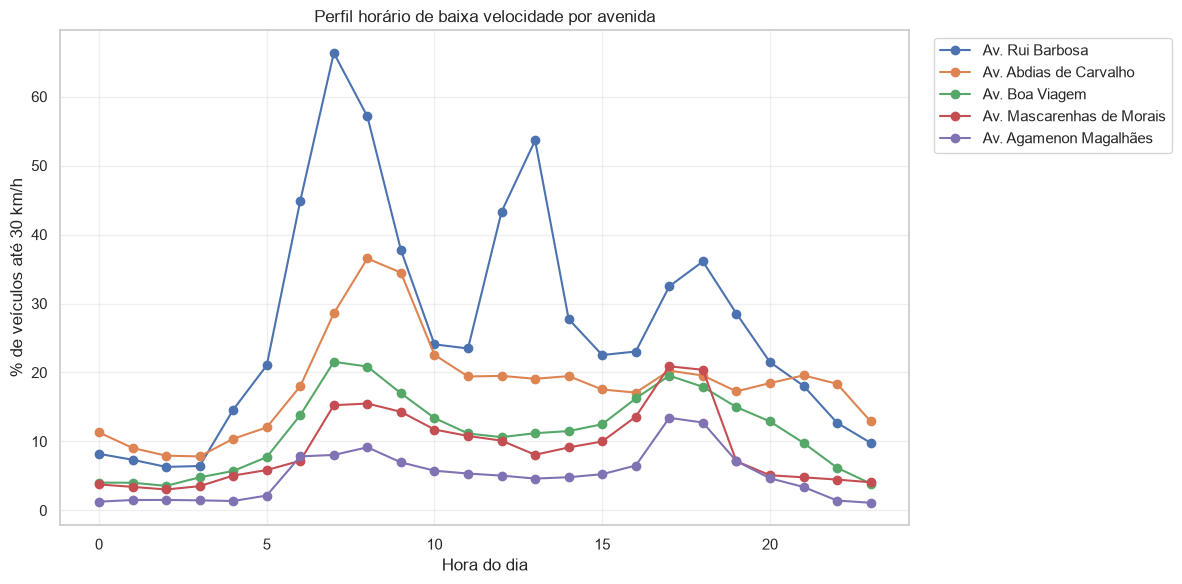


Salvo: resultados/perfil_horario_avenidas.png


In [43]:
def perfil_horario_avenida(nome_avenida, df_registros, tabela_pontos):
    equipamentos_avenida = tabela_pontos.loc[
        tabela_pontos["avenida"] == nome_avenida, "equipamento"
    ].unique()

    dados = df_registros[df_registros["equipamento"].isin(equipamentos_avenida)]

    perfil = (
        dados.groupby("hora", observed=True)
        .agg(observacoes=("total_observacoes", "sum"), baixa_ate30=("qtd_ate30", "sum"))
        .reset_index()
    )
    perfil["perc_ate30"] = perfil["baixa_ate30"] / perfil["observacoes"] * 100
    perfil = perfil.sort_values("hora")
    return perfil

print("HORÁRIO MAIS CRÍTICO POR AVENIDA (% de veículos até 30 km/h por hora)\n")
perfis_avenidas = {}
for nome_avenida in resumo_avenidas["avenida"]:
    perfil = perfil_horario_avenida(nome_avenida, df, pts_com_avenida)
    perfis_avenidas[nome_avenida] = perfil
    if len(perfil) == 0 or perfil["observacoes"].sum() == 0:
        continue
    pico = perfil.loc[perfil["perc_ate30"].idxmax()]
    print(f"{nome_avenida}: pico às {int(pico['hora'])}h ({pico['perc_ate30']:.1f}% baixa velocidade)")

plt.figure(figsize=(12, 6))
for nome_avenida in resumo_avenidas["avenida"].head(6):  # as 6 piores, pra não poluir o gráfico
    perfil = perfis_avenidas[nome_avenida]
    if perfil["observacoes"].sum() > 0:
        plt.plot(perfil["hora"], perfil["perc_ate30"], marker="o", label=nome_avenida)

plt.xlabel("Hora do dia")
plt.ylabel("% de veículos até 30 km/h")
plt.title("Perfil horário de baixa velocidade por avenida")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("resultados/perfil_horario_avenidas.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSalvo: resultados/perfil_horario_avenidas.png")

In [44]:
ALTERNATIVAS_RUI_BARBOSA = {
    "Rua do Futuro": ["RUA DO FUTURO"],
    "Rua Bruno Maia": ["BRUNO MAIA"],
}

for nome_rua, apelidos in ALTERNATIVAS_RUI_BARBOSA.items():
    encontrados = pts[pts["endereco_normalizado"].apply(
        lambda e: any(apelido in e for apelido in apelidos)
    )]
    print(f"\n{nome_rua}: {len(encontrados)} ponto(s) encontrado(s)")
    if len(encontrados) > 0:
        display(
            encontrados[["equipamento", "faixa", "local_instalacao",
                         "perc_ate30", "velocidade_media_estimada", "observacoes"]]
        )


Rua do Futuro: 0 ponto(s) encontrado(s)

Rua Bruno Maia: 0 ponto(s) encontrado(s)


In [45]:
print("Distribuição de perc_dias_baixa em pontos_definitivos:")
display(pontos_definitivos["perc_dias_baixa"].describe())

zero_dias_criticos = pontos_definitivos[pontos_definitivos["perc_dias_baixa"] == 0]
print(f"\nPontos com 0% de dias críticos: {len(zero_dias_criticos)} de {len(pontos_definitivos)}")

display(
    zero_dias_criticos[["equipamento", "faixa", "perc_ate30", "perc_dias_baixa",
                          "dias_analisados", "observacoes", "local_instalacao"]]
    .sort_values("perc_ate30", ascending=False)
    .head(20)
)

Distribuição de perc_dias_baixa em pontos_definitivos:


count    133.000000
mean      14.749089
std       30.230863
min        0.000000
25%        0.000000
50%        0.000000
75%        9.170306
max      100.000000
Name: perc_dias_baixa, dtype: float64


Pontos com 0% de dias críticos: 69 de 133


,equipamento,faixa,perc_ate30,perc_dias_baixa,dias_analisados,observacoes,local_instalacao
49,CTTU-9455,B,27.439000,0.0,236,1831878.0,"AV. BEBERIBE SANTA CRUZ FUTEBOL CLUBE, 2960"
109,CTTU-9474,B,26.870730,0.0,129,1087209.0,"AV. ENG. JOSÂ ESTELITA, APÃ S O VIADUTO DAS C..."
38,CTTU-9451,B,26.493989,0.0,230,2897812.0,"AV. RUI BARBOSA, N. 1397"
34,CTTU-9450,A,22.799280,0.0,235,1271470.0,"AV. REPUBLICA DO LIBANO, N. 115 - PINA"
41,CTTU-9452,B,20.085710,0.0,234,995449.0,RUA ARQUITETO LUIZ NUNES ENTRE O N.315 E 379
102,CTTU-9472,C,19.588363,0.0,227,1810866.0,"AV. MAL. MASCARENHAS DE MORAES, N. 2686"
78,CTTU-9465,C,19.043341,0.0,236,1980267.0,"AV. CONS. AGUIAR, N. 4620"
57,CTTU-9459,B,18.994346,0.0,235,3159835.0,"AV. ENG. ABDIAS DE CARVALHO, ENTRE OS Nº 1785 ..."
56,CTTU-9459,A,16.435655,0.0,235,2646624.0,"AV. ENG. ABDIAS DE CARVALHO, ENTRE OS Nº 1785 ..."
114,CTTU-9477,A,16.419300,0.0,108,1235077.0,"RUA SÃO MIGUEL, APÃ S O N. 1165"


In [46]:
nao_localizados_historico = localizacao_equipamentos[~localizacao_equipamentos["localizado"]]
print(f"Equipamentos do histórico SEM localização: {len(nao_localizados_historico)}")
display(nao_localizados_historico[["equipamento_historico", "id_numerico"]])

ids_no_historico = set(equipamentos_df["id_numerico"].dropna().astype(int))
ids_na_fiscalizacao = set(
    pd.to_numeric(equipamentos_fiscalizacao_corrigido["identificacao_equipamento"], errors="coerce")
    .dropna().astype(int)
)
ids_orfaos = ids_na_fiscalizacao - ids_no_historico

print(f"\nEquipamentos cadastrados na fiscalização mas SEM registro no histórico de Lombadas: {len(ids_orfaos)}")
equipamentos_orfaos = equipamentos_fiscalizacao_corrigido[
    pd.to_numeric(equipamentos_fiscalizacao_corrigido["identificacao_equipamento"], errors="coerce")
    .isin(ids_orfaos)
]
display(
    equipamentos_orfaos[["identificacao_equipamento", "local_instalacao", "latitude",
                           "longitude", "velocidade_fiscalizada"]]
)

Equipamentos do histórico SEM localização: 1


,equipamento_historico,id_numerico
4,CTTU-9441,9441



Equipamentos cadastrados na fiscalização mas SEM registro no histórico de Lombadas: 0


,identificacao_equipamento,local_instalacao,latitude,longitude,velocidade_fiscalizada


In [47]:
diario["dia_baixa_velocidade_25"] = diario["perc_ate30"] >= 25
diario["dia_baixa_velocidade_30"] = diario["perc_ate30"] >= 30

teste_limiares = (
    diario.groupby(["equipamento", "faixa"], observed=True)
    .agg(
        dias_analisados=("data", "nunique"),
        dias_criticos_50=("dia_baixa_velocidade", "sum"),
        dias_criticos_30=("dia_baixa_velocidade_30", "sum"),
        dias_criticos_25=("dia_baixa_velocidade_25", "sum"),
    )
    .reset_index()
)
teste_limiares["perc_dias_30"] = teste_limiares["dias_criticos_30"] / teste_limiares["dias_analisados"] * 100

print("Quantos pontos passam a ter dias críticos com limiar de 30% em vez de 50%:")
print(f"Com 50%: {(teste_limiares['dias_criticos_50'] > 0).sum()} de {len(teste_limiares)} pontos")
print(f"Com 30%: {(teste_limiares['dias_criticos_30'] > 0).sum()} de {len(teste_limiares)} pontos")

Quantos pontos passam a ter dias críticos com limiar de 30% em vez de 50%:
Com 50%: 65 de 135 pontos
Com 30%: 92 de 135 pontos


In [48]:
print("Arquivos de origem do CTTU-9441 no histórico:")
print(lombadas_historico[lombadas_historico["equipamento"] == "CTTU-9441"]["arquivo_origem"].unique())

print("\nID extraído:", extrair_numero_equipamento("CTTU-9441"))

print("\nExiste na base de fiscalização com esse número?")
display(
    equipamentos_fiscalizacao_corrigido[
        pd.to_numeric(equipamentos_fiscalizacao_corrigido["identificacao_equipamento"], errors="coerce") == 9441
    ]
)

Arquivos de origem do CTTU-9441 no histórico:
<StringArray>
[           'Lombadas 2025 - Abril.csv',
           'Lombadas 2025 - Agosto.csv',
        'Lombadas 2025 - Fevereiro.csv',
          'Lombadas 2025 - Janeiro.csv',
            'Lombadas 2025 - Julho.csv',
            'Lombadas 2025 - Junho.csv',
            'Lombadas 2025 - Março.csv',
 'Lombadas 2025 - Maio.csv (corrigido)']
Length: 8, dtype: str

ID extraído: 9441

Existe na base de fiscalização com esse número?


,ï»¿_id,tipo_equipamento,registro_inmetro,numero_serie_fabricante,identificacao_equipamento,local_instalacao,sentido_fiscalizacao,latitude,longitude,faixas_fiscalizadas,velocidade_fiscalizada,vmd,periodo_vmd,id_numerico


In [49]:
horario_diario = (
    df.loc[df["total_observacoes"] > 0, ["equipamento", "faixa", "data", "hora", "total_observacoes", "qtd_ate30"]]
    .groupby(["equipamento", "faixa", "data", "hora"], observed=True)
    .agg(observacoes=("total_observacoes", "sum"), baixa_ate30=("qtd_ate30", "sum"))
    .reset_index()
)
horario_diario["perc_ate30"] = horario_diario["baixa_ate30"] / horario_diario["observacoes"] * 100

perfil_por_ponto = (
    horario_diario.groupby(["equipamento", "faixa", "hora"], observed=True)
    .agg(observacoes=("observacoes", "sum"), baixa_ate30=("baixa_ate30", "sum"))
    .reset_index()
)
perfil_por_ponto["perc_ate30"] = perfil_por_ponto["baixa_ate30"] / perfil_por_ponto["observacoes"] * 100

hora_pico_por_ponto = (
    perfil_por_ponto.sort_values("perc_ate30", ascending=False)
    .drop_duplicates(subset=["equipamento", "faixa"], keep="first")
    [["equipamento", "faixa", "hora"]]
    .rename(columns={"hora": "hora_pico"})
)

horario_diario_com_pico = horario_diario.merge(hora_pico_por_ponto, on=["equipamento", "faixa"], how="inner")
no_horario_pico = horario_diario_com_pico[horario_diario_com_pico["hora"] == horario_diario_com_pico["hora_pico"]].copy()
no_horario_pico["dia_critico_no_pico"] = no_horario_pico["perc_ate30"] >= 50

recorrencia_pico = (
    no_horario_pico.groupby(["equipamento", "faixa"], observed=True)
    .agg(
        hora_pico=("hora_pico", "first"),
        dias_com_dados_no_pico=("data", "nunique"),
        dias_criticos_no_pico=("dia_critico_no_pico", "sum"),
        perc_ate30_no_pico=("perc_ate30", "mean"),
    )
    .reset_index()
)
recorrencia_pico["perc_dias_criticos_no_pico"] = (
    recorrencia_pico["dias_criticos_no_pico"] / recorrencia_pico["dias_com_dados_no_pico"] * 100
)

print("COMPARAÇÃO: métrica antiga (dia inteiro) vs. nova (horário de pico)\n")
comparacao_metricas = pontos_definitivos[
    ["equipamento", "faixa", "perc_ate30", "perc_dias_baixa"]
].merge(
    recorrencia_pico[["equipamento", "faixa", "hora_pico", "perc_ate30_no_pico", "perc_dias_criticos_no_pico"]],
    on=["equipamento", "faixa"], how="left"
)
comparacao_metricas = comparacao_metricas.rename(columns={
    "perc_dias_baixa": "perc_dias_criticos_DIA_INTEIRO",
})
display(comparacao_metricas.sort_values("perc_ate30", ascending=False).head(20))

comparacao_metricas.to_csv("resultados/comparacao_metricas_recorrencia.csv", index=False, encoding="utf-8-sig")
print("\nSalvo: resultados/comparacao_metricas_recorrencia.csv")

COMPARAÇÃO: métrica antiga (dia inteiro) vs. nova (horário de pico)



,equipamento,faixa,perc_ate30,perc_dias_criticos_DIA_INTEIRO,hora_pico,perc_ate30_no_pico,perc_dias_criticos_no_pico
0,CTTU-9460,C,88.510883,100.000000,15.0,93.229349,100.000000
1,CTTU-9111,B,83.719224,100.000000,19.0,93.272804,100.000000
2,CTTU-9472,D,82.374649,100.000000,18.0,85.628142,100.000000
3,CTTU-9457,A,81.853954,100.000000,17.0,91.743939,100.000000
4,CTTU-9460,A,80.839181,98.297872,5.0,88.218377,97.706422
5,CTTU-9458,B,80.223012,100.000000,18.0,90.728952,100.000000
6,CTTU-9457,B,78.191436,100.000000,17.0,87.843222,100.000000
7,CTTU-9460,B,77.195224,97.872340,17.0,84.143512,95.495495
8,CTTU-9447,C,74.288397,72.807018,18.0,75.853463,83.098592
9,CTTU-9111,A,73.722293,99.549550,17.0,85.067082,99.532710



Salvo: resultados/comparacao_metricas_recorrencia.csv


In [50]:
pontos_definitivos = pontos_definitivos.merge(
    recorrencia_pico[["equipamento", "faixa", "hora_pico", "perc_ate30_no_pico", "perc_dias_criticos_no_pico"]],
    on=["equipamento", "faixa"], how="left"
)

# Reordenar o ranking usando a métrica mais defensável
pontos_definitivos = pontos_definitivos.sort_values(
    ["perc_ate30", "perc_dias_criticos_no_pico"], ascending=False
)

pontos_definitivos.to_csv("resultados/pontos_definitivos_velocidade_localizacao.csv", index=False, encoding="utf-8-sig")
print("pontos_definitivos atualizado e salvo.")

pontos_definitivos atualizado e salvo.


In [51]:

velocidade_referencia = 32.111843


rotas_estudo_caso = pd.DataFrame({
    "rota": [
        "Referência (Av. Rui Barbosa)",
        "Alternativa (Rua do Futuro / Bruno Maia)"
    ],
    "distancia_km": [
        distancia_referencia_km,
        np.nan
    ],
    "velocidade_kmh": [
        velocidade_referencia,
        np.nan
    ],
    "fonte_velocidade": [
        "estimativa histórica dos dados CTTU",
        "sem dado histórico disponível"
    ]
})

# Tempo somente quando existir distância E velocidade observada
rotas_estudo_caso["tempo_min"] = (
    rotas_estudo_caso["distancia_km"] /
    rotas_estudo_caso["velocidade_kmh"]
) * 60

print("=" * 70)
print("ESTUDO DE CASO — AV. RUI BARBOSA x ALTERNATIVA")
print("=" * 70)

display(rotas_estudo_caso)

print("\nRota de referência:")
print(f"Distância: {distancia_referencia_km:.2f} km")
print(f"Velocidade histórica estimada: {velocidade_referencia:.2f} km/h")

tempo_referencia = (
    distancia_referencia_km /
    velocidade_referencia
) * 60

print(f"Tempo estimado da referência: {tempo_referencia:.2f} minutos")

# Salvar
os.makedirs("resultados", exist_ok=True)

rotas_estudo_caso.to_csv(
    "resultados/estudo_caso_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nArquivo salvo:")
print("resultados/estudo_caso_final.csv")

ESTUDO DE CASO — AV. RUI BARBOSA x ALTERNATIVA


,rota,distancia_km,velocidade_kmh,fonte_velocidade,tempo_min
0,Referência (Av. Rui Barbosa),7.93621,32.111843,estimativa histórica dos dados CTTU,14.828567
1,Alternativa (Rua do Futuro / Bruno Maia),NaN,NaN,sem dado histórico disponível,NaN



Rota de referência:
Distância: 7.94 km
Velocidade histórica estimada: 32.11 km/h
Tempo estimado da referência: 14.83 minutos

Arquivo salvo:
resultados/estudo_caso_final.csv
